# Clustering Grid Search Analysis: Builds, Demos, and Renos

## Preliminaries

In [1]:
# Imports

# General
import numpy as np
import pandas as pd
import json
import itertools
import time
from IPython.display import display
import random
from joblib import Memory
from datetime import datetime

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'iframe' # For plotly graphs to render in this environment

# Geography
import geopandas as gpd
from shapely.geometry import Point, Polygon


# NLP
import re
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
import nltk, pprint
pprint.pp(nltk.data.path)
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn
from nltk.corpus import names
import pycountry

# sk-learn modeling
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.decomposition import TruncatedSVD
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.base import clone
from sklearn.metrics import (
        silhouette_score,
        silhouette_samples,
        davies_bouldin_score, 
        calinski_harabasz_score)


['C:\\Users\\emshe/nltk_data',
 'C:\\Users\\emshe\\anaconda3\\envs\\capstone_env\\nltk_data',
 'C:\\Users\\emshe\\anaconda3\\envs\\capstone_env\\share\\nltk_data',
 'C:\\Users\\emshe\\anaconda3\\envs\\capstone_env\\lib\\nltk_data',
 'C:\\Users\\emshe\\AppData\\Roaming\\nltk_data',
 'C:\\nltk_data',
 'D:\\nltk_data',
 'E:\\nltk_data']


In [2]:
# Set directory

PATH = "C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA"

In [3]:
# Load permits data

permits_df = pd.read_csv(f"{PATH}/PERMITS/issued_building_permits_filter_dwelling_purposes_preprocessed.csv")

# examine_df('permits dataframe',permits_df)

## Define helper functions

In [29]:
# Define function to examine dataframes

def examine_df(name,df,
               include_stats = True,
               include_sample = True):
    
    """
    Check basic info about a dataframe df
    """
    
    print(f"\n\nNumber of records in the {name} is: {len(df)}\n")
    print(f"\nNumber of features in the {name} is: {len(df.columns)}\n")
    print(f"The columns in the {name} are: {df.columns}\n")
    print(f"\n Other info about {name}:\n")
    display(df.info())
    if include_stats == True:
        print(f'\n Basic statistical info about {name}:\n')
        display(df.describe())
    if include_sample == True:
        print(f"\n\nSample of records in the {name}:")
        display(df.head(5))

In [30]:
# Define functions to detect binary columns vs. continuous functions

def is_binary(series: pd.Series) -> bool:

    '''
    Detect binary columns in series
    '''
    
    vals = series.dropna().unique()
    return set(vals).issubset({0, 1}) and len(vals) <= 2

def select_binary_cols(X):

    '''
    Select subset of binary columns
    '''
    
    return [c for c in X.columns
            if c != "project_description"
            and is_binary(X[c])]

def select_cont_cols(X):

    '''
    Select subset of continuous columns
    '''
    
    cols = []
    for c in X.columns:
        if c == "project_description":
            continue
        s = X[c]
        # numeric dtype
        if np.issubdtype(s.dtype, np.number):
            if not is_binary(s):
                cols.append(c)
    return cols

In [31]:
# Define function to drop trivial columns from dataframe

def drop_trivial(df):

    """
    Drop all trivial (all 1 or all 0) columns from a dataframe
    """

    n_rows = len(df)
    
    to_drop = []

    for col in df.columns:
        if is_binary(df[col]) and (df[col].sum() == 0 or df[col].sum() == n_rows):
            to_drop.append(col)

    df = df.drop(columns = to_drop)
    return df

In [32]:
# Define function to make permit sub-dataframe model ready

def model_ready(df):

    """
    Drop columns that won't be used in modeling
    """

    return df.drop(columns = ['issue_date', 'geom','nbhd','zone'])

## Split Up Permits

In [8]:
# Get dataframes of new builds (one with all info, one for modeling)

is_new_building = (permits_df['type_of_work_new_building'] == 1) | (permits_df['permit_category_new_build_low_density_housing'] == 1) | (permits_df['permit_category_new_build_standalone_laneway'] == 1)

builds_df = permits_df[is_new_building]

builds_df = drop_trivial(builds_df)

cluster_builds_df = model_ready(builds_df)

# examine_df('buildings dataframe', cluster_builds_df)

In [9]:
# Get dataframe of renovations (one with all info, one for modeling)

renos_df = permits_df[permits_df['permit_category_renovation_residential_lower_complexity'] == 1]

renos_df = drop_trivial(renos_df)

cluster_renos_df = model_ready(renos_df)

# examine_df('renovations dataframe', cluster_renos_df)

In [10]:
# Get dataframe of demolitions

demos_df = permits_df[permits_df['type_of_work_demolition_deconstruction'] == 1]

demos_df = drop_trivial(demos_df)

cluster_demos_df = model_ready(demos_df)

# examine_df('demolitions dataframe', cluster_demos_df)

In [11]:
# Get dataframe with no renovations, no demolitions

not_reno = (permits_df['permit_category_renovation_residential_lower_complexity'] == 0)

not_demo = (permits_df['type_of_work_demolition_deconstruction'] == 0)

restr_df = permits_df[not_reno & not_demo]

restr_df = drop_trivial(restr_df)

cluster_restr_df = model_ready(restr_df)

# examine_df('restricted dataframe (no renovations or demolitions)', cluster_restr_df)

In [21]:
# Save demo, reno, and build csvs

demos_df.to_csv(f"{PATH}/PERMITS/demos.csv", encoding="utf-8", index = False)

renos_df.to_csv(f"{PATH}/PERMITS/renos.csv", encoding="utf-8", index = False)

builds_df.to_csv(f"{PATH}/PERMITS/builds.csv", encoding="utf-8", index = False)

## K-Means Grid Searches

### Builds

In [37]:
# Load first builds grid search results

builds_results_list = []

builds_results_01 = read_grid_results_csv('BUILDS/KMEANS','01_kmeans_grid_results_builds.csv')

builds_results_list.append(builds_results_01)

# examine_df('first builds results', builds_results_01)

In [38]:
# Load second builds grid search results

builds_results_02 = read_grid_results_csv('BUILDS/KMEANS','02_kmeans_grid_results_builds.csv')

builds_results_list.append(builds_results_02)

# examine_df('second builds results', builds_results_02)

In [39]:
# Merge vertically (row bind)

builds_results = pd.concat(
    builds_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

# examine_df('all build results', builds_results)



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.3810  | kmeans__n_clusters=9.0, prep__text__svd__n_components=5.0, prep__text__tfidf__max_features=1000.0, n_clusters_found=9.0, aic=nan, bic=nan, avg_loglik=-17764.389829574437  | time=0.93 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=3398.0133  | kmeans__n_clusters=7.0, prep__text__svd__n_components=5.0, prep__text__tfidf__max_features=1000.0, n_clusters_found=7.0, aic=nan, bic=nan, avg_loglik=-21354.96435687232  | time=0.95 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=0.8601  | kmeans__n_clusters=7.0, prep__text__svd__n_components=5.0, prep__text__tfidf__max_features=750.0, n_clusters_found=7.0, aic=nan, bic=nan, avg_loglik=-21389.735572642283  | time=0.96 min

Metric: inertia  (lower is better)
  • inertia=17175.8146  | kmeans__n_clusters=10.0, prep__text__svd__n_components=5.0

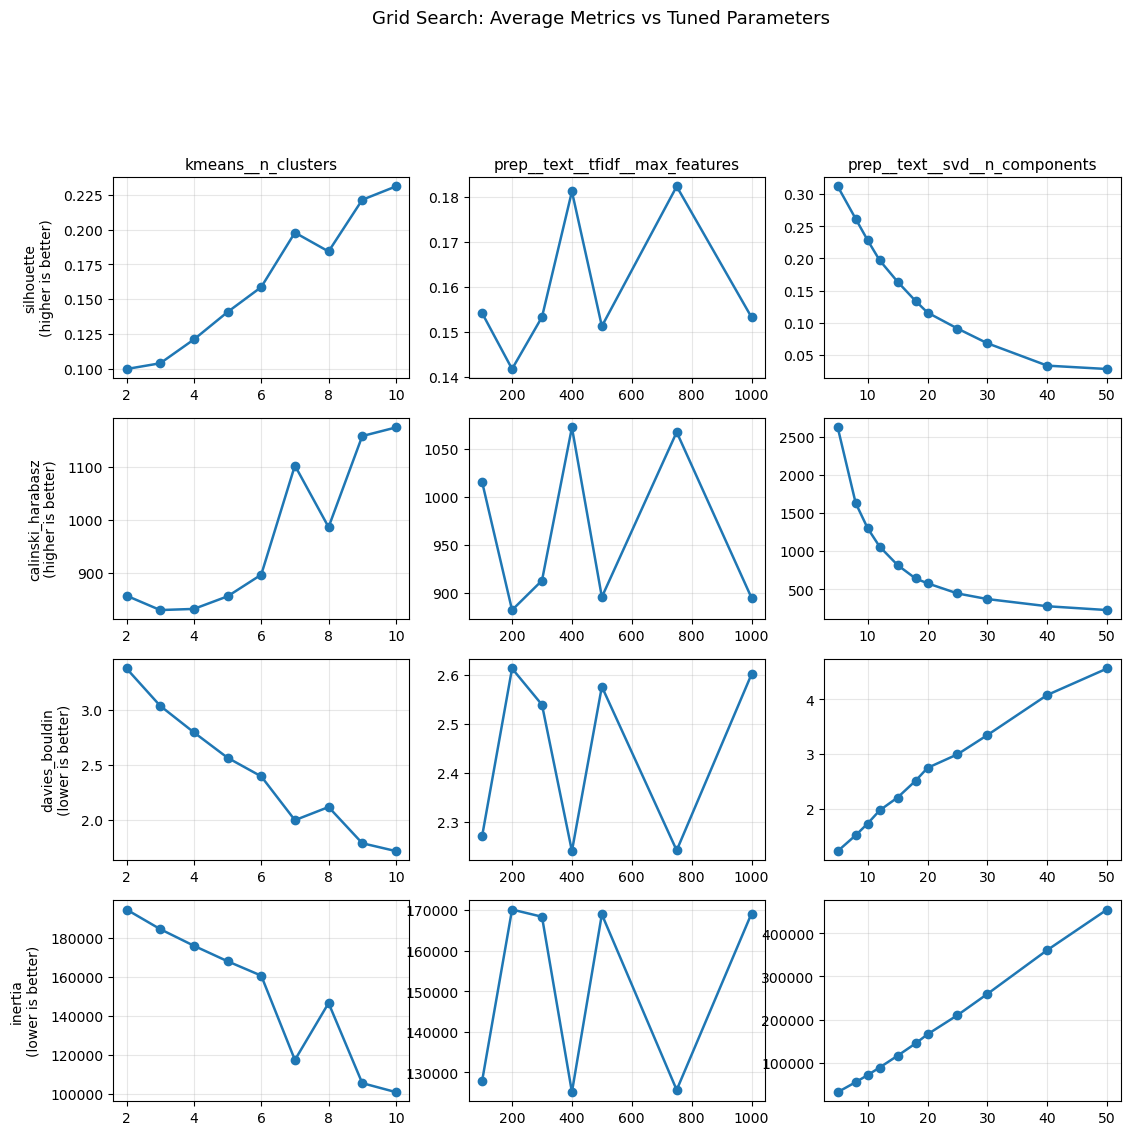



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin


  - 3D plot for metric: inertia




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.02 min
- 3D metric plots: 0.14 min

Total runtime: 0.16 minutes.


In [40]:
# Evaluate all builds results with grid evaluator

grid_evaluator(builds_results, model = 'kmeans')

For new builds, the clustering generally performed better with more clusters and fewer SVD components. Metrics fluctuated substantially as we varied tf-idf feature count, though 400was a good choice.

**Best silhouette score so far:**  silhouette=0.3810  | kmeans__n_clusters=9.0, prep__text__svd__n_components=5.0, prep__text__tfidf__max_features=1000.0, aic=nan, bic=nan, avg_loglik=-17764.389829574437  | time=0.93 min

### Renovations

In [41]:
# Load first renos grid search results

renos_results_list = []

renos_results_01 = read_grid_results_csv('RENOS/KMEANS','01_kmeans_grid_results_renos.csv')

renos_results_list.append(renos_results_01)

# examine_df('first renovations results', renos_results_01)

In [42]:
# Load second renos grid search results

renos_results_02 = read_grid_results_csv('RENOS/KMEANS','02_kmeans_grid_results_renos.csv')

renos_results_list.append(renos_results_02)

# examine_df('second renovations results', renos_results_02)

In [43]:
# Load third renos grid search results

renos_results_03 = read_grid_results_csv('RENOS/KMEANS','03_kmeans_grid_results_renos.csv')

renos_results_list.append(renos_results_03)

# examine_df('third renovations results', renos_results_03)

In [44]:
# Merge vertically (row bind)

renos_results = pd.concat(
    renos_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

# examine_df('all renovation results', renos_results)



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.3837  | kmeans__n_clusters=6.0, prep__text__svd__n_components=5.0, prep__text__tfidf__max_features=500.0, n_clusters_found=6.0, aic=nan, bic=nan, avg_loglik=-16695.000478536513  | time=0.44 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=3671.4298  | kmeans__n_clusters=8.0, prep__text__svd__n_components=2.0, prep__text__tfidf__max_features=400.0, n_clusters_found=8.0, aic=nan, bic=nan, avg_loglik=-6732.821332137793  | time=0.51 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=0.7910  | kmeans__n_clusters=6.0, prep__text__svd__n_components=5.0, prep__text__tfidf__max_features=500.0, n_clusters_found=6.0, aic=nan, bic=nan, avg_loglik=-16695.000478536513  | time=0.44 min

Metric: inertia  (lower is better)
  • inertia=5626.8681  | kmeans__n_clusters=10.0, prep__text__svd__n_components=2.0, p

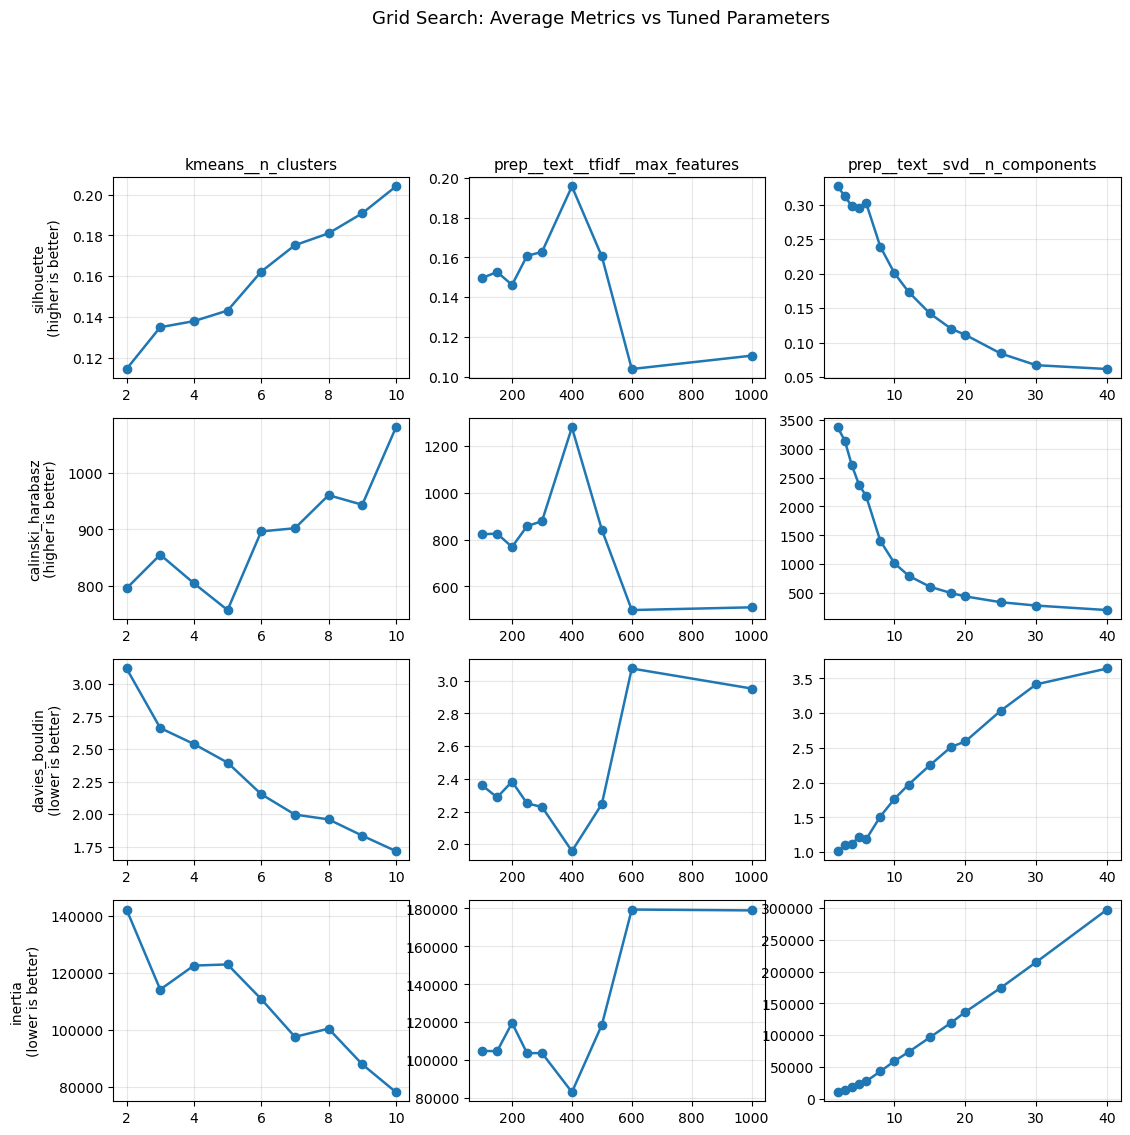



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin


  - 3D plot for metric: inertia




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.02 min
- 3D metric plots: 0.14 min

Total runtime: 0.16 minutes.


In [45]:
# Evaluate all reno results with grid evaluator

grid_evaluator(renos_results)

For renovations, the clustering generally performed better when the number of clusters was higher, the number of SVD components was lower, and the number of tf-idf tokens was below 600.

**Best silhouette score so far:** silhouette=0.3837  | kmeans__n_clusters=6.0, prep__text__svd__n_components=5.0, prep__text__tfidf__max_features=500.0, aic=nan, bic=nan, avg_loglik=-16695.000478536513  | time=0.44 min

In [45]:
# Check which combinations have been tested for the renovations dataframe

renos_tested = list_tested_param_combos(renos_results)
display(renos_tested)

637 unique parameter combinations found.


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,trials
0,2,5,100,1
1,2,5,150,1
2,2,5,200,1
3,2,5,250,1
4,2,5,300,1
...,...,...,...,...
632,10,30,200,1
633,10,30,250,1
634,10,30,300,1
635,10,30,400,1


### Demolitions

In [99]:
# Load first demos grid search results

demos_results_list = []

demos_results_01 = read_grid_results_csv('DEMOS/KMEANS','01_kmeans_grid_results_demos.csv')

demos_results_list.append(demos_results_01)

# examine_df('first demo results', demos_results_01)

In [100]:
# Load first demos grid search results

demos_results_02 = read_grid_results_csv('DEMOS/KMEANS','02_kmeans_grid_results_demos.csv')

demos_results_list.append(demos_results_02)

# examine_df('second demo results', demos_results_02)

In [101]:
# Merge vertically (row bind)

demos_results = pd.concat(
    demos_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

# examine_df('all demolition results', demos_results)

In [108]:
# Evaluate all demo results with grid evaluator

grid_evaluator(demos_results)



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.6079  | kmeans__n_clusters=10.0, prep__text__svd__n_components=8.0, prep__text__tfidf__max_features=180.0, n_clusters_found=10.0, aic=nan, bic=nan, avg_loglik=-8535.688657496785  | time=0.17 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=3381.5945  | kmeans__n_clusters=10.0, prep__text__svd__n_components=8.0, prep__text__tfidf__max_features=180.0, n_clusters_found=10.0, aic=nan, bic=nan, avg_loglik=-8535.688657496785  | time=0.17 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=0.6445  | kmeans__n_clusters=10.0, prep__text__svd__n_components=8.0, prep__text__tfidf__max_features=300.0, n_clusters_found=10.0, aic=nan, bic=nan, avg_loglik=-8891.855078188924  | time=0.17 min

Metric: inertia  (lower is better)
  • inertia=8535.6887  | kmeans__n_clusters=10.0, prep__text__svd__n_components=8.

Our initial two grid searches indicate results are better when the number of clusters is high and the number of SVD components is low. There is a less of clear pattern when it comes to the number of tf-idf tokens selected.

**Best silhouette score so far:**  • silhouette=0.6079  | kmeans__n_clusters=10.0, prep__text__svd__n_components=8.0, prep__text__tfidf__max_features=180.0, aic=nan, bic=nan, avg_loglik=-8535.688657496785  | time=0.17 min

In [105]:
# Restrict to strong silhouette scores to check for good configurations with fewer clusters.

demos_results_strong = demos_results[demos_results['silhouette'] > .4]

examine_df('strong demo results', demos_results_strong)



Number of records in the strong demo results is: 116


Number of features in the strong demo results is: 12

The columns in the strong demo results are: Index(['kmeans__n_clusters', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'fit_time_s', 'n_clusters_found',
       'aic', 'bic', 'avg_loglik'],
      dtype='object')


 Other info about strong demo results:

<class 'pandas.core.frame.DataFrame'>
Index: 116 entries, 18 to 408
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   kmeans__n_clusters               116 non-null    int64  
 1   prep__text__svd__n_components    116 non-null    int64  
 2   prep__text__tfidf__max_features  116 non-null    int64  
 3   inertia                          116 non-null    float64
 4   silhouette                       116 non-null    float64
 

None


 Basic statistical info about strong demo results:



,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found,aic,bic,avg_loglik
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,0.0,0.0,112.000000
mean,8.362069,10.715517,391.551724,29294.005466,0.492888,1295.581682,1.111457,10.344756,8.362069,NaN,NaN,-29294.920017
std,1.398114,2.721272,191.545674,12848.086835,0.059578,595.128555,0.242748,0.261964,1.398114,NaN,NaN,13057.563794
min,5.000000,8.000000,180.000000,8535.688657,0.403958,437.691578,0.644512,9.913800,5.000000,NaN,NaN,-72546.024439
25%,7.000000,8.000000,200.000000,21328.579171,0.436163,899.582126,0.924990,10.114484,7.000000,NaN,NaN,-36573.145179
50%,9.000000,10.000000,300.000000,26633.843435,0.489559,1168.225933,1.103043,10.326064,9.000000,NaN,NaN,-26629.433953
75%,10.000000,12.000000,600.000000,36573.145179,0.536773,1464.554527,1.246171,10.515361,10.000000,NaN,NaN,-21240.753204
max,10.000000,20.000000,700.000000,72546.024439,0.607948,3381.594476,1.758132,11.156984,10.000000,NaN,NaN,-8535.688657




Sample of records in the strong demo results:


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found,aic,bic,avg_loglik
18,6,10,200,35780.301789,0.414671,948.449705,1.214381,10.619663,6,NaN,NaN,NaN
27,8,10,200,28061.808208,0.492207,1087.707907,1.178461,10.540555,8,NaN,NaN,NaN
28,8,10,500,26615.741081,0.486592,1191.092213,1.085041,11.027547,8,NaN,NaN,NaN
29,8,10,600,26615.741081,0.486592,1191.092213,1.085041,10.717014,8,NaN,NaN,NaN
96,5,8,450,30659.287894,0.429282,1090.226122,1.165817,10.343431,5,NaN,NaN,-30659.287894


In [107]:
# Restrict to strong silhouette scores to check for good configurations with five clusters.

demos_results_few_clusters = demos_results_strong[demos_results_strong['n_clusters_found'] == 5]

examine_df('strong demo results with five clusters', demos_results_few_clusters)



Number of records in the strong demo results with five clusters is: 3


Number of features in the strong demo results with five clusters is: 12

The columns in the strong demo results with five clusters are: Index(['kmeans__n_clusters', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'fit_time_s', 'n_clusters_found',
       'aic', 'bic', 'avg_loglik'],
      dtype='object')


 Other info about strong demo results with five clusters:

<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 96 to 98
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   kmeans__n_clusters               3 non-null      int64  
 1   prep__text__svd__n_components    3 non-null      int64  
 2   prep__text__tfidf__max_features  3 non-null      int64  
 3   inertia                          3 non-null      

None


 Basic statistical info about strong demo results with five clusters:



,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found,aic,bic,avg_loglik
count,3.0,3.0,3.000000,3.000000e+00,3.000000,3.000000,3.000000,3.000000,3.0,0.0,0.0,3.000000e+00
mean,5.0,8.0,583.333333,3.065929e+04,0.429282,1090.226122,1.165817,10.388469,5.0,NaN,NaN,-3.065929e+04
std,0.0,0.0,125.830574,5.752150e-12,0.000000,0.000000,0.000000,0.323392,0.0,NaN,NaN,5.144879e-12
min,5.0,8.0,450.000000,3.065929e+04,0.429282,1090.226122,1.165817,10.089957,5.0,NaN,NaN,-3.065929e+04
25%,5.0,8.0,525.000000,3.065929e+04,0.429282,1090.226122,1.165817,10.216694,5.0,NaN,NaN,-3.065929e+04
50%,5.0,8.0,600.000000,3.065929e+04,0.429282,1090.226122,1.165817,10.343431,5.0,NaN,NaN,-3.065929e+04
75%,5.0,8.0,650.000000,3.065929e+04,0.429282,1090.226122,1.165817,10.537726,5.0,NaN,NaN,-3.065929e+04
max,5.0,8.0,700.000000,3.065929e+04,0.429282,1090.226122,1.165817,10.732020,5.0,NaN,NaN,-3.065929e+04




Sample of records in the strong demo results with five clusters:


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,fit_time_s,n_clusters_found,aic,bic,avg_loglik
96,5,8,450,30659.287894,0.429282,1090.226122,1.165817,10.343431,5,NaN,NaN,-30659.287894
97,5,8,600,30659.287894,0.429282,1090.226122,1.165817,10.732020,5,NaN,NaN,-30659.287894
98,5,8,700,30659.287894,0.429282,1090.226122,1.165817,10.089957,5,NaN,NaN,-30659.287894


In [109]:
# Check grid evaluator

grid_evaluator(demos_results_few_clusters, run_trends=False, run_3d=False)



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.4293  | kmeans__n_clusters=5.0, prep__text__svd__n_components=8.0, prep__text__tfidf__max_features=450.0, n_clusters_found=5.0, aic=nan, bic=nan, avg_loglik=-30659.287893790195  | time=0.17 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=1090.2261  | kmeans__n_clusters=5.0, prep__text__svd__n_components=8.0, prep__text__tfidf__max_features=450.0, n_clusters_found=5.0, aic=nan, bic=nan, avg_loglik=-30659.287893790195  | time=0.17 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=1.1658  | kmeans__n_clusters=5.0, prep__text__svd__n_components=8.0, prep__text__tfidf__max_features=450.0, n_clusters_found=5.0, aic=nan, bic=nan, avg_loglik=-30659.287893790195  | time=0.17 min

Metric: inertia  (lower is better)
  • inertia=30659.2879  | kmeans__n_clusters=5.0, prep__text__svd__n_components=8.0, 

In [99]:
# Check which combinations have been tested for the demolitions dataframe

demos_tested = list_tested_param_combos(demos_results, model = 'kmeans')

examine_df('Kmeans configs tested for demos', demos_tested)

410 unique parameter combinations found.


Number of records in the Kmeans configs tested for demos is: 410


Number of features in the Kmeans configs tested for demos is: 4

The columns in the Kmeans configs tested for demos are: Index(['kmeans__n_clusters', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'trials'],
      dtype='object')


 Other info about Kmeans configs tested for demos:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 4 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   kmeans__n_clusters               410 non-null    int64
 1   prep__text__svd__n_components    410 non-null    int64
 2   prep__text__tfidf__max_features  410 non-null    int64
 3   trials                           410 non-null    int64
dtypes: int64(4)
memory usage: 12.9 KB


None


 Basic statistical info about Kmeans configs tested for demos:



,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,trials
count,410.000000,410.000000,410.000000,410.000000
mean,6.868293,17.370732,386.536585,1.043902
std,2.108829,7.166147,188.132516,0.205128
min,2.000000,8.000000,180.000000,1.000000
25%,5.000000,10.000000,200.000000,1.000000
50%,7.000000,18.000000,300.000000,1.000000
75%,9.000000,25.000000,600.000000,1.000000
max,10.000000,30.000000,700.000000,2.000000




Sample of records in the Kmeans configs tested for demos:


,kmeans__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,trials
0,2,10,200,1
1,2,10,500,1
2,2,10,600,1
3,2,20,200,1
4,2,20,500,1


## Gaussian Mixture Models Grid Searches

### Test grid search evaluation functions

In [107]:
# Test print top configurations function for GMM

print_top_configs(gmm_builds_results, model = 'gmm')


=== Top parameter configurations by metric ===

Metric: bic  (lower is better)
  • bic=-841821.1643  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, inertia=nan  | time=1.06 min

Metric: aic  (lower is better)
  • aic=-849477.2822  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, inertia=nan  | time=1.06 min

Metric: avg_loglik  (higher is better)
  • avg_loglik=44.9925  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, inertia=nan  | time=1.06 min

Metric: silhouette  (higher is better)
  • silhouette=0.2056  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=10, prep__text__tfidf__max_features=400, 

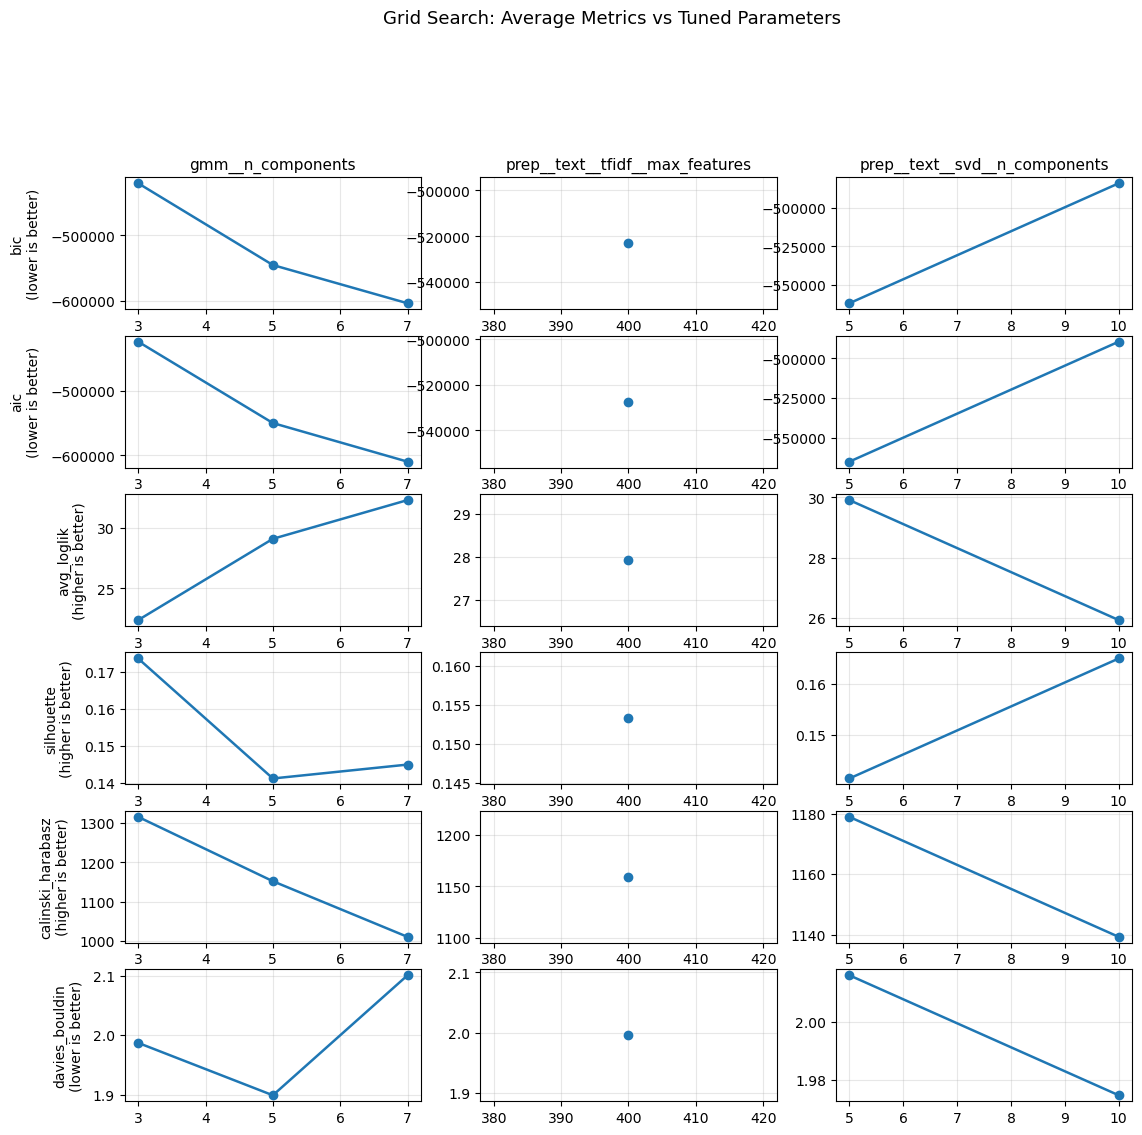

In [120]:
# Test function to plot metric trends with GMM

plot_metric_trends(gmm_builds_results, model = 'gmm')

In [121]:
# Test function to plot 3D Grid Search visualization

plot_grid_3d_metric(gmm_builds_results, metric = 'silhouette', model = 'gmm')

### Builds

In [50]:
# Load first builds GMM grid search results

gmm_builds_results_list = []

gmm_builds_results_01 = read_grid_results_csv('BUILDS/GMM','01_gmm_grid_results_builds.csv')

gmm_builds_results_list.append(gmm_builds_results_01)

# examine_df('first builds results from GMM', gmm_builds_results_01)

In [51]:
# Load second builds GMM grid search results

gmm_builds_results_02 = read_grid_results_csv('BUILDS/GMM','02_gmm_grid_results_builds.csv')

gmm_builds_results_list.append(gmm_builds_results_02)

# examine_df('first builds results from GMM', gmm_builds_results_02)

In [52]:
# Merge vertically (row bind)

gmm_builds_results = pd.concat(
    gmm_builds_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

# examine_df('all GMM builds results', gmm_builds_results)

In [96]:
# Check which GMM combinations have been tested for the builds dataframe

gmm_builds_tested = list_tested_param_combos(gmm_builds_results, model = 'gmm')

examine_df('GMM configurations tested for builds', gmm_builds_tested)

24 unique parameter combinations found.


Number of records in the GMM configurations tested for builds is: 24


Number of features in the GMM configurations tested for builds is: 7

The columns in the GMM configurations tested for builds are: Index(['gmm__n_components', 'gmm__covariance_type', 'gmm__reg_covar',
       'gmm__n_init', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'trials'],
      dtype='object')


 Other info about GMM configurations tested for builds:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   gmm__n_components                24 non-null     int64  
 1   gmm__covariance_type             24 non-null     object 
 2   gmm__reg_covar                   24 non-null     float64
 3   gmm__n_init                      24 non-null     int64  
 4   prep__text__svd__n

None


 Basic statistical info about GMM configurations tested for builds:



,gmm__n_components,gmm__reg_covar,gmm__n_init,prep__text__svd__n_components,prep__text__tfidf__max_features,trials
count,24.000000,24.000000,24.0,24.00000,24.0,24.0
mean,5.000000,0.000051,3.0,7.50000,400.0,1.0
std,1.668115,0.000051,0.0,2.55377,0.0,0.0
min,3.000000,0.000001,3.0,5.00000,400.0,1.0
25%,3.000000,0.000001,3.0,5.00000,400.0,1.0
50%,5.000000,0.000051,3.0,7.50000,400.0,1.0
75%,7.000000,0.000100,3.0,10.00000,400.0,1.0
max,7.000000,0.000100,3.0,10.00000,400.0,1.0




Sample of records in the GMM configurations tested for builds:


,gmm__n_components,gmm__covariance_type,gmm__reg_covar,gmm__n_init,prep__text__svd__n_components,prep__text__tfidf__max_features,trials
0,3,diag,0.000001,3,5,400,1
1,3,diag,0.000001,3,10,400,1
2,3,diag,0.000100,3,5,400,1
3,3,diag,0.000100,3,10,400,1
4,3,full,0.000001,3,5,400,1




Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: bic  (lower is better)
  • bic=-841821.1643  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, inertia=nan, n_clusters_found=7  | time=1.06 min

Metric: aic  (lower is better)
  • aic=-849477.2822  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, inertia=nan, n_clusters_found=7  | time=1.06 min

Metric: avg_loglik  (higher is better)
  • avg_loglik=44.9925  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=5, prep__text__tfidf__max_features=400, inertia=nan, n_clusters_found=7  | time=1.06 min

Metric: silhouette  (higher is better)
  • silhouette=0.2754  | gmm__covariance_type=full, gmm__n_component

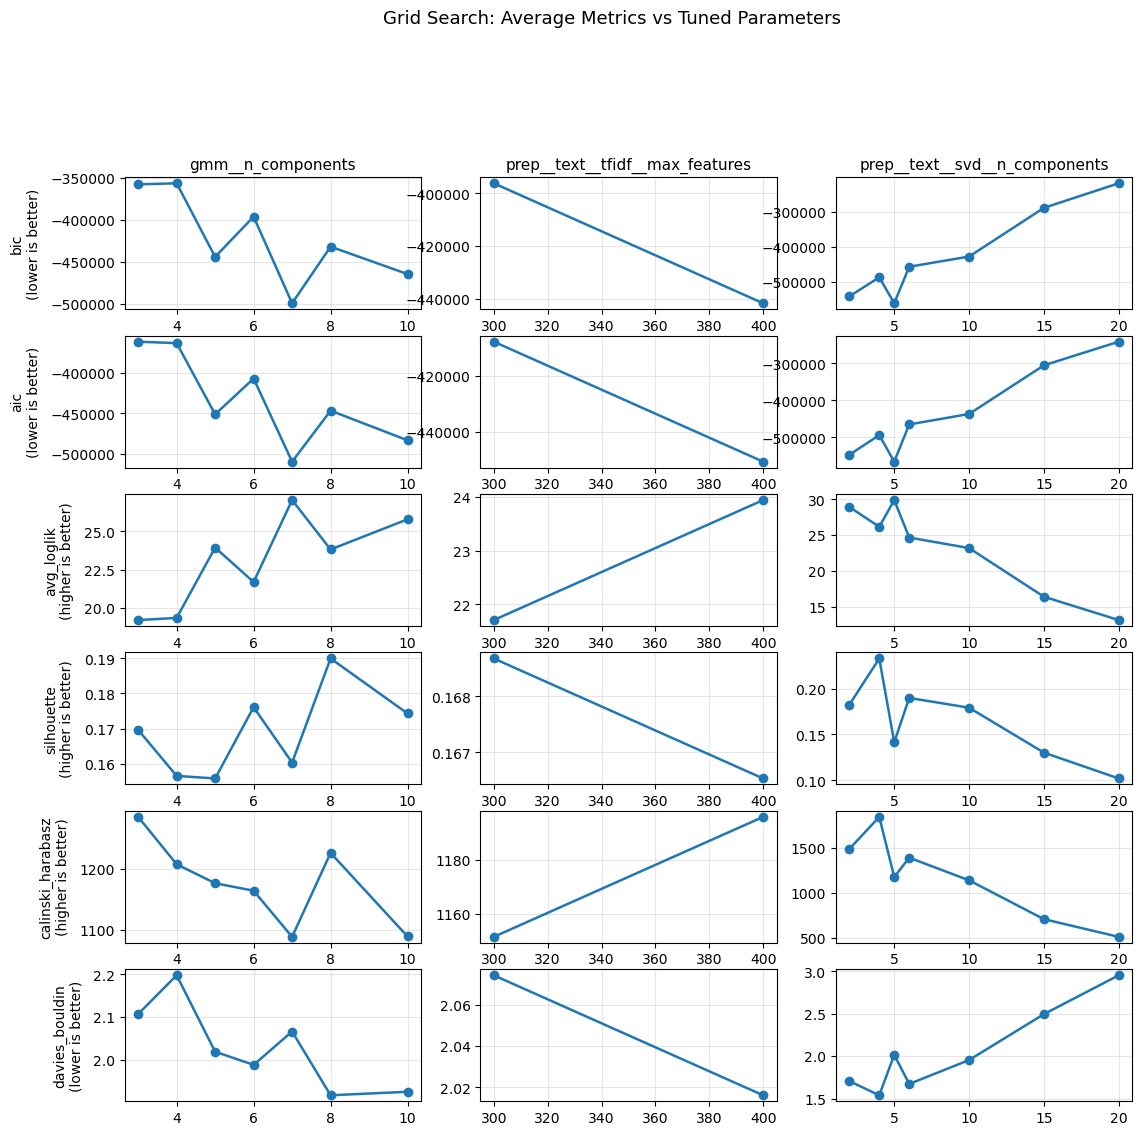



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: bic


  - 3D plot for metric: aic


  - 3D plot for metric: avg_loglik


  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.03 min
- 3D metric plots: 0.21 min

Total runtime: 0.24 minutes.


In [53]:
# Test full grid evaluator

grid_evaluator(gmm_builds_results, model = 'gmm')

For GMM:

**Best silhouette so far:** silhouette=0.2754  | gmm__covariance_type=full, gmm__n_components=4, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=4, prep__text__tfidf__max_features=400, inertia=nan  | time=0.92 min

### Renovations

In [54]:
# Load first builds GMM grid search results

gmm_renos_results_list = []

gmm_renos_results_01 = read_grid_results_csv('RENOS/GMM','01_gmm_grid_results_renos.csv')

gmm_renos_results_list.append(gmm_renos_results_01)

# examine_df('first renos results from GMM', gmm_renos_results_01)

In [55]:
# Merge vertically (row bind)

gmm_renos_results = pd.concat(
    gmm_renos_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

# examine_df('all GMM renos results', gmm_renos_results)



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: bic  (lower is better)
  • bic=-664071.6949  | gmm__covariance_type=diag, gmm__n_components=10, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=2, prep__text__tfidf__max_features=500, inertia=nan, n_clusters_found=10  | time=0.51 min

Metric: aic  (lower is better)
  • aic=-665668.1566  | gmm__covariance_type=diag, gmm__n_components=10, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=2, prep__text__tfidf__max_features=500, inertia=nan, n_clusters_found=10  | time=0.51 min

Metric: avg_loglik  (higher is better)
  • avg_loglik=42.2937  | gmm__covariance_type=diag, gmm__n_components=10, gmm__n_init=3, gmm__reg_covar=1e-06, prep__text__svd__n_components=2, prep__text__tfidf__max_features=500, inertia=nan, n_clusters_found=10  | time=0.51 min

Metric: silhouette  (higher is better)
  • silhouette=0.3414  | gmm__covariance_type=full, gmm__n_com

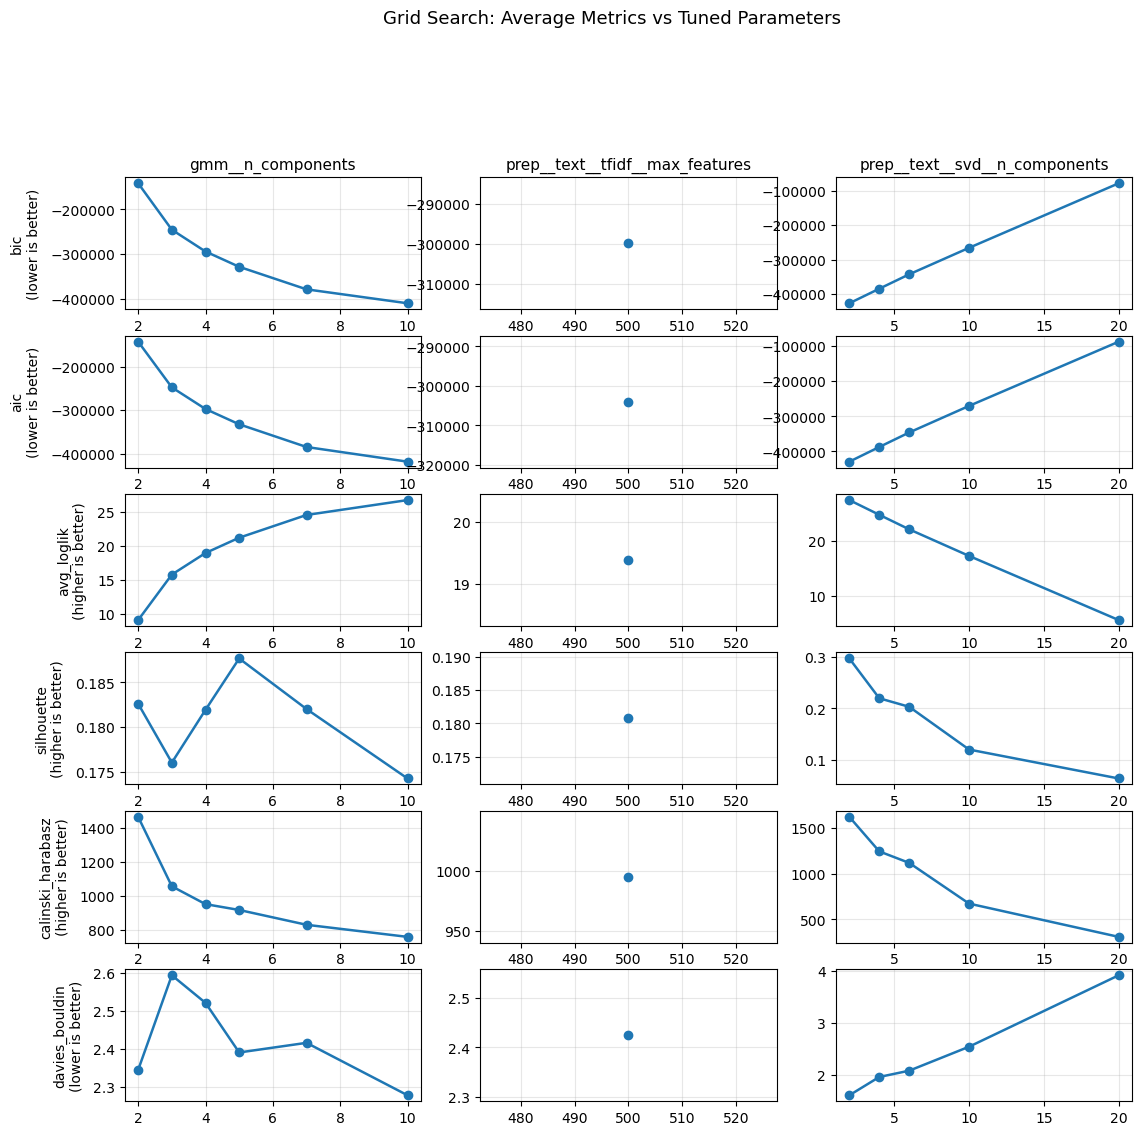



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: bic


  - 3D plot for metric: aic


  - 3D plot for metric: avg_loglik


  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.03 min
- 3D metric plots: 0.21 min

Total runtime: 0.24 minutes.


In [56]:
# Test full grid evaluator

grid_evaluator(gmm_renos_results, model = 'gmm')

For GMM:

**Best silhouette so far:** silhouette=0.3414  | gmm__covariance_type=full, gmm__n_components=5, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=2, prep__text__tfidf__max_features=500, inertia=nan  | time=0.49 min

### Demolitions

In [57]:
# Load first builds GMM grid search results

gmm_demos_results_list = []

gmm_demos_results_01 = read_grid_results_csv('DEMOS/GMM','01_gmm_grid_results_demos.csv')

gmm_demos_results_list.append(gmm_demos_results_01)

# examine_df('first demos results from GMM', gmm_demos_results_01)

In [58]:
# Merge vertically (row bind)

gmm_demos_results = pd.concat(
    gmm_demos_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

# examine_df('all GMM demos results', gmm_demos_results)



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: bic  (lower is better)
  • bic=-491177.7985  | gmm__covariance_type=full, gmm__n_components=8, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=20, prep__text__tfidf__max_features=200, inertia=nan, n_clusters_found=8  | time=0.19 min

Metric: aic  (lower is better)
  • aic=-515911.6573  | gmm__covariance_type=full, gmm__n_components=8, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=20, prep__text__tfidf__max_features=200, inertia=nan, n_clusters_found=8  | time=0.19 min

Metric: avg_loglik  (higher is better)
  • avg_loglik=45.7954  | gmm__covariance_type=full, gmm__n_components=8, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=20, prep__text__tfidf__max_features=200, inertia=nan, n_clusters_found=8  | time=0.19 min

Metric: silhouette  (higher is better)
  • silhouette=0.5520  | gmm__covariance_type=full, gmm__n_com

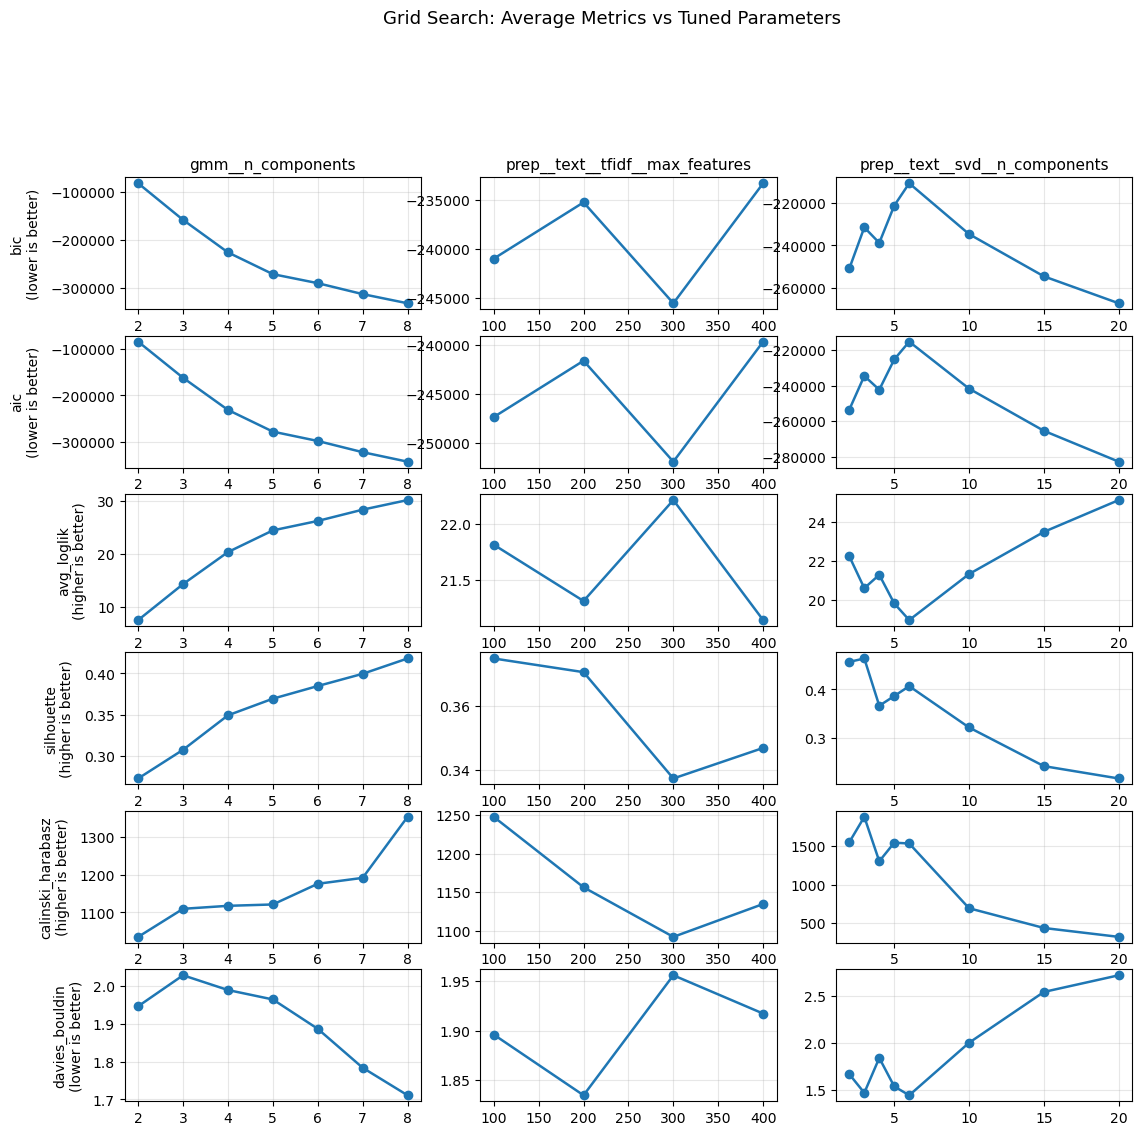



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: bic


  - 3D plot for metric: aic


  - 3D plot for metric: avg_loglik


  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.02 min
- 3D metric plots: 0.21 min

Total runtime: 0.23 minutes.


In [59]:
# Test full grid evaluator

grid_evaluator(gmm_demos_results, model = 'gmm')

For GMM:

**Best silhouette score so far**: Metric: silhouette  (higher is better)
  • silhouette=0.5520  | gmm__covariance_type=full, gmm__n_components=7, gmm__n_init=3, gmm__reg_covar=0.0001, prep__text__svd__n_components=6, prep__text__tfidf__max_features=100, inertia=nan  | time=0.19 min

## Hierarchical (Agglomerative) Clustering

### Builds

In [60]:
# Load first builds agg grid search results

agg_builds_results_list = []

agg_builds_results_01 = read_grid_results_csv('BUILDS/AGG','01_agg_grid_results_builds.csv')

agg_builds_results_list.append(agg_builds_results_01)

# examine_df('first builds results from agg', agg_builds_results_01)

In [61]:
# Load second builds agg grid search results

agg_builds_results_02 = read_grid_results_csv('BUILDS/AGG','02_agg_grid_results_builds.csv')

agg_builds_results_list.append(agg_builds_results_02)

# examine_df('second builds results from agg', agg_builds_results_02)

In [62]:
# Merge vertically (row bind)

agg_builds_results = pd.concat(
    agg_builds_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

# examine_df('all agg builds results', agg_builds_results)



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.4137  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=9, prep__text__svd__n_components=4, prep__text__tfidf__max_features=100, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=9, agg__linkage=ward  | time=1.79 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=4189.8836  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=9, prep__text__svd__n_components=4, prep__text__tfidf__max_features=100, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=9, agg__linkage=ward  | time=1.79 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=0.7665  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=8, prep__text__svd__n_components=4, prep__text__tfidf__max_features=500, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clu

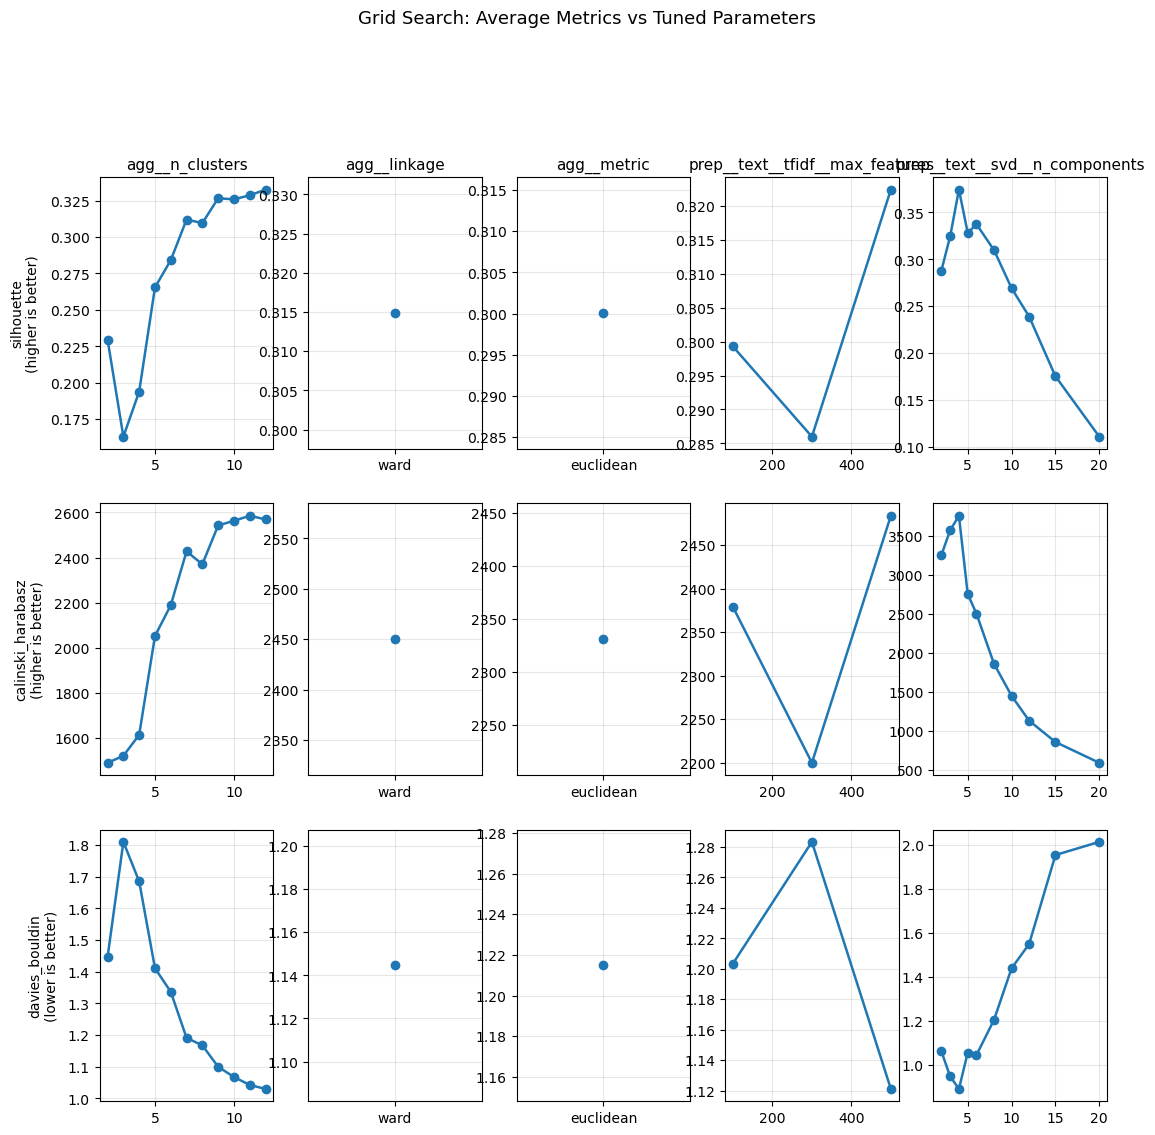



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.03 min
- 3D metric plots: 0.11 min

Total runtime: 0.13 minutes.


In [63]:
# Test full grid evaluator

grid_evaluator(agg_builds_results, model = 'agg')

For agglomerative:

**Best silhouette score so far**:  silhouette=0.4137  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=9, prep__text__svd__n_components=4, prep__text__tfidf__max_features=100, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, agg__linkage=ward  | time=1.79 min

### Renovations

In [67]:
# Load first builds agg grid search results

agg_renos_results_list = []

agg_renos_results_01 = read_grid_results_csv('RENOS/AGG','01_agg_grid_results_renos.csv')

agg_renos_results_list.append(agg_renos_results_01)

# examine_df('first renos results from agg', agg_renos_results_01)

In [68]:
# Load first builds agg grid search results

agg_renos_results_02 = read_grid_results_csv('RENOS/AGG','02_agg_grid_results_renos.csv')

agg_renos_results_list.append(agg_renos_results_02)

# examine_df('first renos results from agg', agg_renos_results_02)

In [69]:
# Merge vertically (row bind)

agg_renos_results = pd.concat(
    agg_renos_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

# examine_df('all agg renos results', agg_renos_results)



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.3524  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=6, prep__text__svd__n_components=3, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=6, agg__linkage=ward, noise_frac=nan  | time=0.88 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=3228.2083  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=5, prep__text__svd__n_components=3, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=5, agg__linkage=ward, noise_frac=nan  | time=0.93 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=0.8237  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=6, prep__text__svd__n_components=5, prep__text__tfidf__max_features=500, inertia=nan, aic=nan

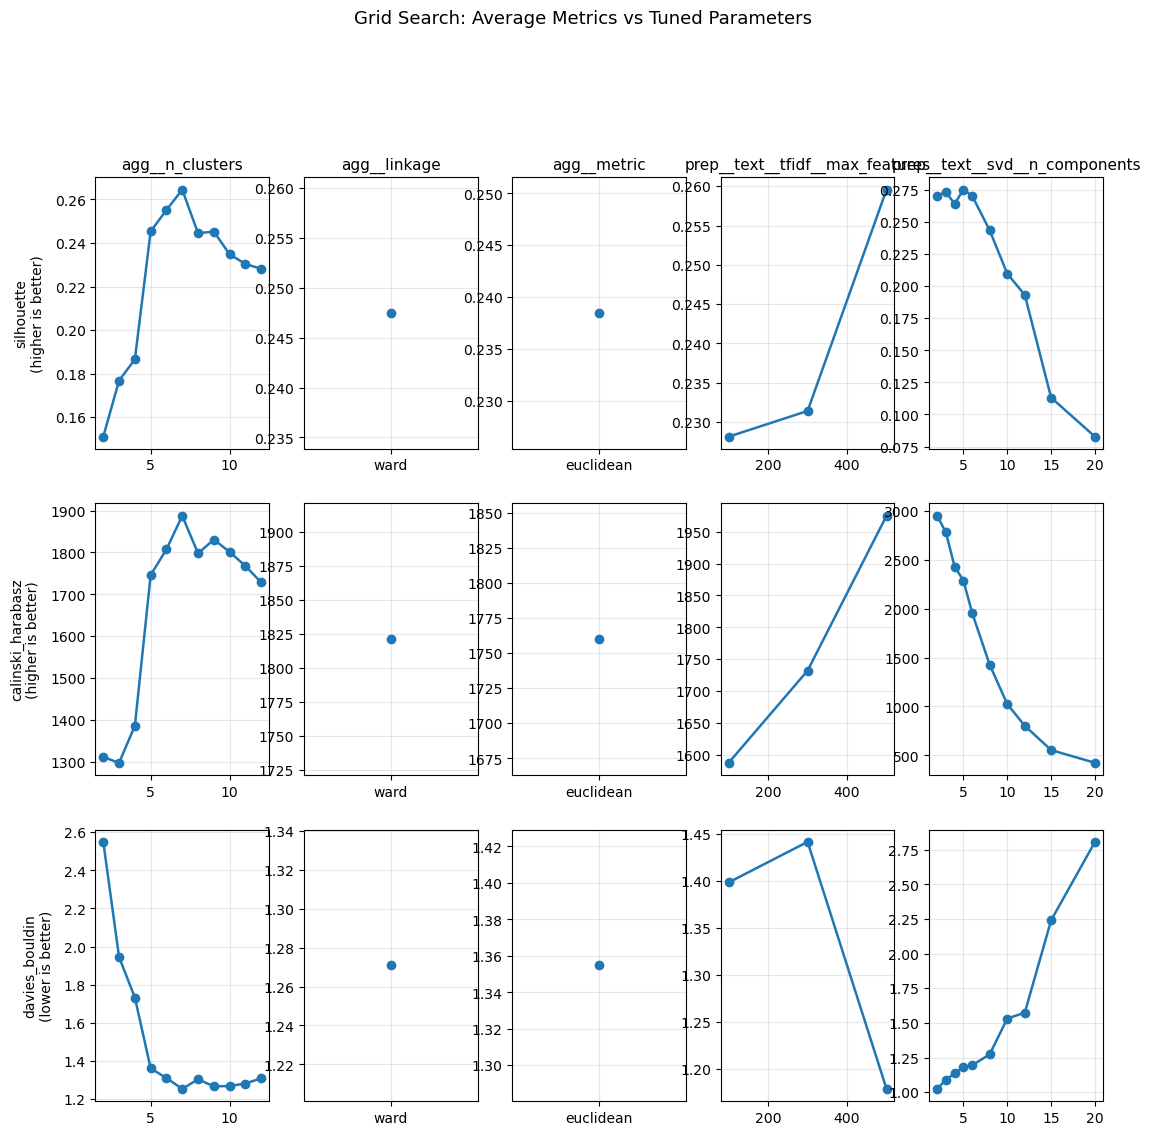



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.02 min
- 3D metric plots: 0.11 min

Total runtime: 0.13 minutes.


In [70]:
# Test full grid evaluator

grid_evaluator(agg_renos_results, model = 'agg')

For agglomerative:

**Best silhouette score so far**: Metric: silhouette  (higher is better)
  • silhouette=0.3524  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=6, prep__text__svd__n_components=3, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=6, agg__linkage=ward, noise_frac=nan  | time=0.88 min

### Demolitions

In [71]:
# Load first builds agg grid search results

agg_demos_results_list = []

agg_demos_results_01 = read_grid_results_csv('DEMOS/AGG','01_agg_grid_results_demos.csv')

agg_demos_results_list.append(agg_demos_results_01)

# examine_df('first demos results from agg', agg_demos_results_01)

In [72]:
# Merge vertically (row bind)

agg_demos_results = pd.concat(
    agg_demos_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

# examine_df('all agg demos results', agg_demos_results)



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.5895  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=8, prep__text__svd__n_components=2, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=8  | time=0.19 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=6079.4500  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=8, prep__text__svd__n_components=2, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=8  | time=0.19 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=0.5463  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=6, prep__text__svd__n_components=2, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=6  | time=0.19 min


Plott

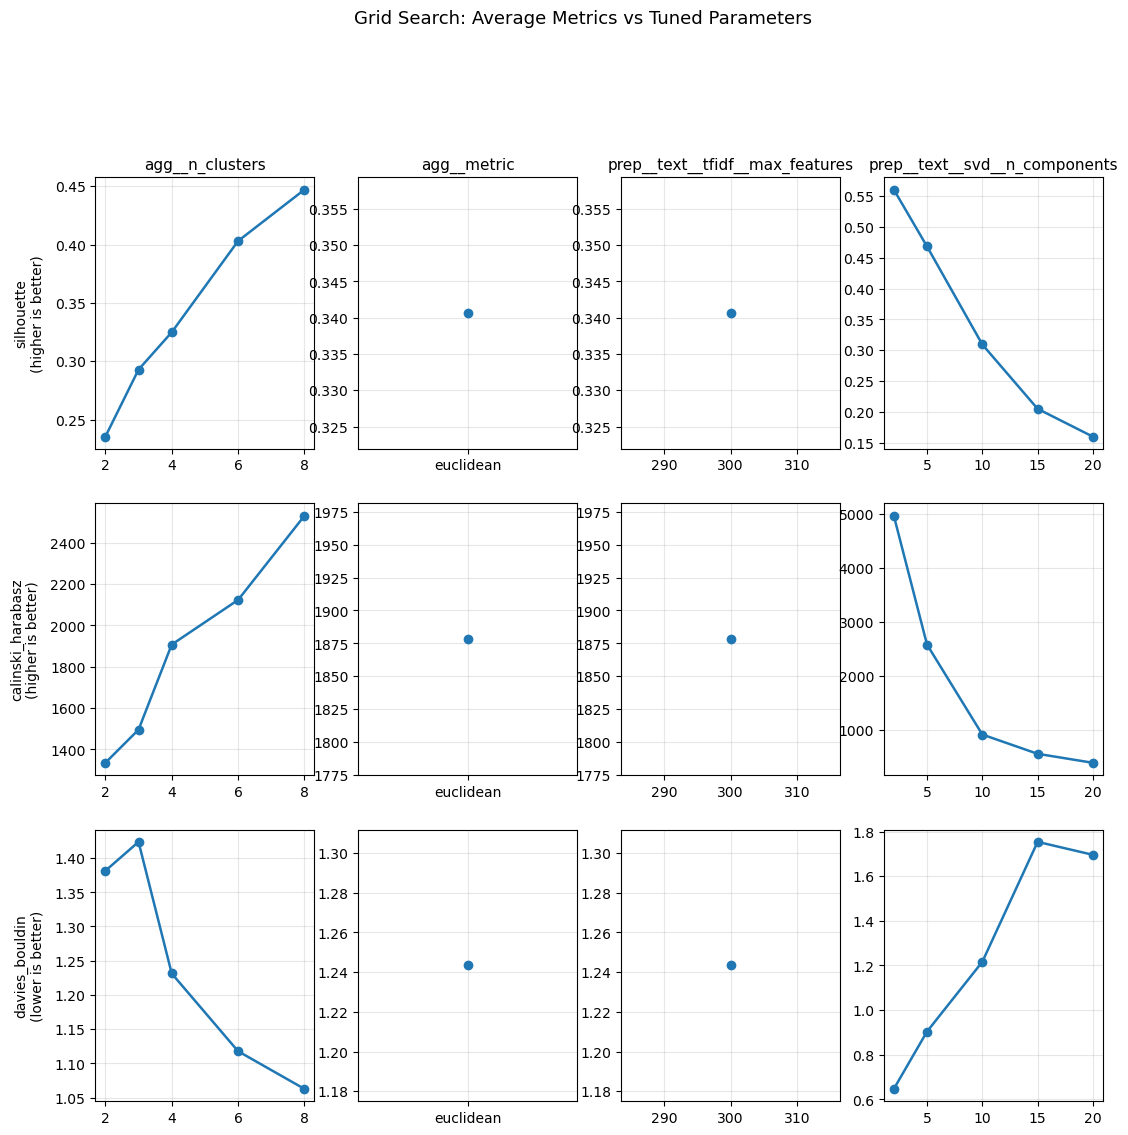



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.02 min
- 3D metric plots: 0.11 min

Total runtime: 0.12 minutes.


In [73]:
# Test full grid evaluator

grid_evaluator(agg_demos_results, model = 'agg')

In [110]:
# Restrict to strong silhouette scores to check for good configurations with fewer clusters.

agg_demos_results_strong = agg_demos_results[agg_demos_results['silhouette'] > .4]

examine_df('strong demo results', agg_demos_results_strong)



Number of records in the strong demo results is: 10


Number of features in the strong demo results is: 14

The columns in the strong demo results are: Index(['agg__distance_threshold', 'agg__metric', 'agg__n_clusters',
       'prep__text__svd__n_components', 'prep__text__tfidf__max_features',
       'inertia', 'silhouette', 'calinski_harabasz', 'davies_bouldin', 'aic',
       'bic', 'avg_loglik', 'fit_time_s', 'n_clusters_found'],
      dtype='object')


 Other info about strong demo results:

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 0 to 22
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   agg__distance_threshold          0 non-null      float64
 1   agg__metric                      10 non-null     object 
 2   agg__n_clusters                  10 non-null     int64  
 3   prep__text__svd__n_components    10 non-null     int64  
 4   prep__text__tfidf__max_

None


 Basic statistical info about strong demo results:



,agg__distance_threshold,agg__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
count,0.0,10.000000,10.000000,10.0,0.0,10.000000,10.000000,10.000000,0.0,0.0,0.0,10.000000,10.000000
mean,NaN,5.200000,4.000000,300.0,NaN,0.530587,3741.830780,0.760662,NaN,NaN,NaN,10.942416,5.200000
std,NaN,2.299758,2.581989,0.0,NaN,0.058170,1721.734861,0.166718,NaN,NaN,NaN,0.795534,2.299758
min,NaN,2.000000,2.000000,300.0,NaN,0.414950,1245.862064,0.546337,NaN,NaN,NaN,9.814699,2.000000
25%,NaN,3.250000,2.000000,300.0,NaN,0.501381,2346.506899,0.651966,NaN,NaN,NaN,10.220053,3.250000
50%,NaN,5.000000,3.500000,300.0,NaN,0.545942,3778.298234,0.733862,NaN,NaN,NaN,11.219692,5.000000
75%,NaN,7.500000,5.000000,300.0,NaN,0.576266,5078.426157,0.900550,NaN,NaN,NaN,11.566454,7.500000
max,NaN,8.000000,10.000000,300.0,NaN,0.589485,6079.450004,1.013099,NaN,NaN,NaN,11.940037,8.000000




Sample of records in the strong demo results:


,agg__distance_threshold,agg__metric,agg__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
0,NaN,euclidean,2,2,300,NaN,0.538341,3402.913679,0.719376,NaN,NaN,NaN,9.926538,2
5,NaN,euclidean,3,2,300,NaN,0.544689,4153.682789,0.571905,NaN,NaN,NaN,9.814699,3
6,NaN,euclidean,3,5,300,NaN,0.414950,1678.446980,1.013099,NaN,NaN,NaN,10.177416,3
10,NaN,euclidean,4,2,300,NaN,0.547196,5845.553982,0.641214,NaN,NaN,NaN,11.499442,4
11,NaN,euclidean,4,5,300,NaN,0.489061,2001.302720,0.978224,NaN,NaN,NaN,11.689890,4


In [111]:
# Restrict to strong silhouette scores to check for good configurations with five or less clusters.

agg_demos_results_few_clusters = agg_demos_results_strong[agg_demos_results_strong['n_clusters_found'] <= 5]

examine_df('strong demo results with five clusters', agg_demos_results_few_clusters)



Number of records in the strong demo results with five clusters is: 5


Number of features in the strong demo results with five clusters is: 14

The columns in the strong demo results with five clusters are: Index(['agg__distance_threshold', 'agg__metric', 'agg__n_clusters',
       'prep__text__svd__n_components', 'prep__text__tfidf__max_features',
       'inertia', 'silhouette', 'calinski_harabasz', 'davies_bouldin', 'aic',
       'bic', 'avg_loglik', 'fit_time_s', 'n_clusters_found'],
      dtype='object')


 Other info about strong demo results with five clusters:

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 0 to 11
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   agg__distance_threshold          0 non-null      float64
 1   agg__metric                      5 non-null      object 
 2   agg__n_clusters                  5 non-null      int64  
 3   prep__text_

None


 Basic statistical info about strong demo results with five clusters:



,agg__distance_threshold,agg__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
count,0.0,5.00000,5.000000,5.0,0.0,5.000000,5.000000,5.000000,0.0,0.0,0.0,5.000000,5.00000
mean,NaN,3.20000,3.200000,300.0,NaN,0.506847,3416.380030,0.784764,NaN,NaN,NaN,10.621597,3.20000
std,NaN,0.83666,1.643168,0.0,NaN,0.056598,1693.187664,0.199847,NaN,NaN,NaN,0.900465,0.83666
min,NaN,2.00000,2.000000,300.0,NaN,0.414950,1678.446980,0.571905,NaN,NaN,NaN,9.814699,2.00000
25%,NaN,3.00000,2.000000,300.0,NaN,0.489061,2001.302720,0.641214,NaN,NaN,NaN,9.926538,3.00000
50%,NaN,3.00000,2.000000,300.0,NaN,0.538341,3402.913679,0.719376,NaN,NaN,NaN,10.177416,3.00000
75%,NaN,4.00000,5.000000,300.0,NaN,0.544689,4153.682789,0.978224,NaN,NaN,NaN,11.499442,4.00000
max,NaN,4.00000,5.000000,300.0,NaN,0.547196,5845.553982,1.013099,NaN,NaN,NaN,11.689890,4.00000




Sample of records in the strong demo results with five clusters:


,agg__distance_threshold,agg__metric,agg__n_clusters,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found
0,NaN,euclidean,2,2,300,NaN,0.538341,3402.913679,0.719376,NaN,NaN,NaN,9.926538,2
5,NaN,euclidean,3,2,300,NaN,0.544689,4153.682789,0.571905,NaN,NaN,NaN,9.814699,3
6,NaN,euclidean,3,5,300,NaN,0.414950,1678.446980,1.013099,NaN,NaN,NaN,10.177416,3
10,NaN,euclidean,4,2,300,NaN,0.547196,5845.553982,0.641214,NaN,NaN,NaN,11.499442,4
11,NaN,euclidean,4,5,300,NaN,0.489061,2001.302720,0.978224,NaN,NaN,NaN,11.689890,4


In [112]:
# Check grid evaluator

grid_evaluator(agg_demos_results_few_clusters, run_trends=False, run_3d=False)



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.5472  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=4, prep__text__svd__n_components=2, prep__text__tfidf__max_features=300, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=4  | time=0.19 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=5845.5540  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=4, prep__text__svd__n_components=2, prep__text__tfidf__max_features=300, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=4  | time=0.19 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=0.5719  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=3, prep__text__svd__n_components=2, prep__text__tfidf__max_features=300, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=3  | time=0.16 min

Metric: inertia  (lower is better)


=== Step

For agglomerative,

**Best silhouette score so far**: silhouette=0.5895  | agg__distance_threshold=nan, agg__metric=euclidean, agg__n_clusters=8, prep__text__svd__n_components=2, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan  | time=0.19 min

## HDBSCAN Clustering

### Builds

In [96]:
# Load second builds hdbscan grid search results

hdbscan_builds_results_list = []

hdbscan_builds_results_02 = read_grid_results_csv('BUILDS/HDBSCAN','02_hdbscan_grid_results_builds.csv')

hdbscan_builds_results_list.append(hdbscan_builds_results_02)

# examine_df('first builds results from hdbscan', hdbscan_builds_results_01)

In [97]:
# Merge vertically (row bind)

hdbscan_builds_results = pd.concat(
    hdbscan_builds_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

# examine_df('all hdbscan builds results', hdbscan_builds_results)



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.3923  | hdbscan__cluster_selection_epsilon=0.02, hdbscan__cluster_selection_method=leaf, hdbscan__min_cluster_size=200, hdbscan__min_samples=10, prep__text__svd__n_components=5, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=21, noise_frac=0.2027683854606931  | time=1.79 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=1364.1004  | hdbscan__cluster_selection_epsilon=0.02, hdbscan__cluster_selection_method=leaf, hdbscan__min_cluster_size=250, hdbscan__min_samples=8, prep__text__svd__n_components=5, prep__text__tfidf__max_features=1000, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=16, noise_frac=0.2037193575655114  | time=1.79 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=1.0279  | hdbscan__cluster_selection_epsilon=

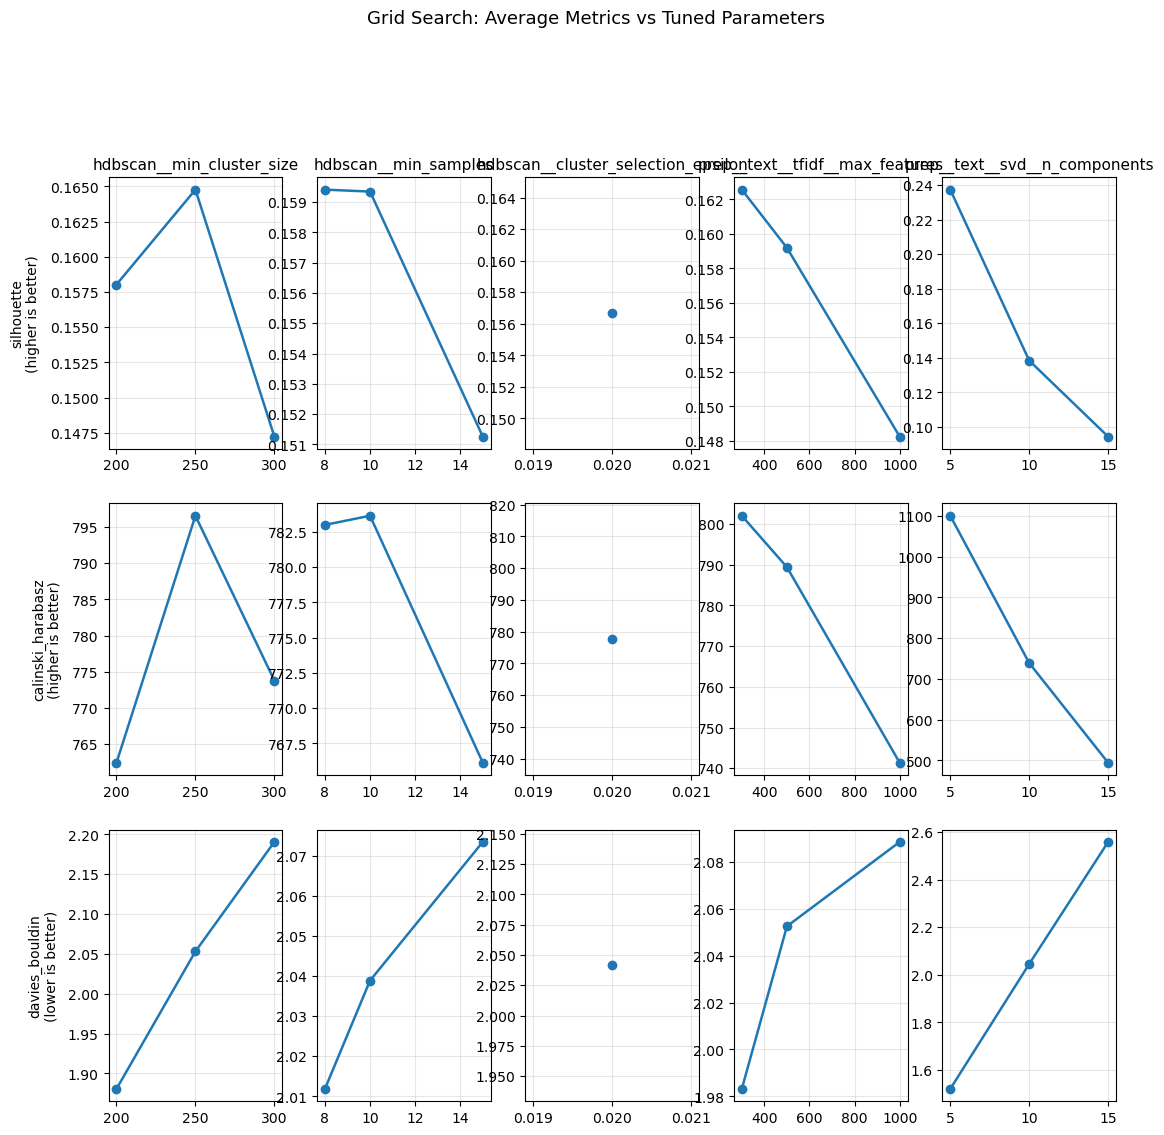



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.04 min
- 3D metric plots: 0.11 min

Total runtime: 0.14 minutes.


In [98]:
# Test full grid evaluator

grid_evaluator(hdbscan_builds_results, model = 'hdbscan')

For hdbscan,

**Best silhouette score so far**:  silhouette=0.3923  | hdbscan__cluster_selection_epsilon=0.02, hdbscan__cluster_selection_method=leaf, hdbscan__min_cluster_size=200, hdbscan__min_samples=10, prep__text__svd__n_components=5, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=21, noise_frac=0.2027683854606931  | time=1.79 min


In [114]:
# Restrict to strong silhouette scores to check for good configurations with fewer clusters.

hdbscan_builds_results_strong = hdbscan_builds_results[hdbscan_builds_results['silhouette'] > .35]

examine_df('strong demo results', hdbscan_builds_results_strong)



Number of records in the strong demo results is: 7


Number of features in the strong demo results is: 16

The columns in the strong demo results are: Index(['hdbscan__cluster_selection_epsilon',
       'hdbscan__cluster_selection_method', 'hdbscan__min_cluster_size',
       'hdbscan__min_samples', 'prep__text__svd__n_components',
       'prep__text__tfidf__max_features', 'inertia', 'silhouette',
       'calinski_harabasz', 'davies_bouldin', 'aic', 'bic', 'avg_loglik',
       'fit_time_s', 'n_clusters_found', 'noise_frac'],
      dtype='object')


 Other info about strong demo results:

<class 'pandas.core.frame.DataFrame'>
Index: 7 entries, 0 to 38
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   hdbscan__cluster_selection_epsilon  7 non-null      float64
 1   hdbscan__cluster_selection_method   7 non-null      object 
 2   hdbscan__min_cluster_size           7 non-

None


 Basic statistical info about strong demo results:



,hdbscan__cluster_selection_epsilon,hdbscan__min_cluster_size,hdbscan__min_samples,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found,noise_frac
count,7.00,7.000000,7.000000,7.0,7.000000,0.0,7.000000,7.000000,7.000000,0.0,0.0,0.0,7.000000,7.000000,7.000000
mean,0.02,214.285714,9.857143,5.0,700.000000,NaN,0.369903,1267.394306,1.059065,NaN,NaN,NaN,108.909625,18.857143,0.190089
std,0.00,24.397502,2.478479,0.0,374.165739,NaN,0.016344,102.955612,0.033555,NaN,NaN,NaN,2.737379,2.115701,0.019706
min,0.02,200.000000,8.000000,5.0,300.000000,NaN,0.351723,1136.331639,1.027899,NaN,NaN,NaN,107.017687,16.000000,0.160397
25%,0.02,200.000000,8.000000,5.0,300.000000,NaN,0.358054,1169.988489,1.034012,NaN,NaN,NaN,107.294305,17.500000,0.179364
50%,0.02,200.000000,10.000000,5.0,1000.000000,NaN,0.368695,1333.568601,1.039287,NaN,NaN,NaN,107.929639,19.000000,0.199070
75%,0.02,225.000000,10.000000,5.0,1000.000000,NaN,0.380253,1348.891237,1.086337,NaN,NaN,NaN,109.043685,20.500000,0.203244
max,0.02,250.000000,15.000000,5.0,1000.000000,NaN,0.392291,1364.100447,1.105571,NaN,NaN,NaN,114.744071,21.000000,0.205938




Sample of records in the strong demo results:


,hdbscan__cluster_selection_epsilon,hdbscan__cluster_selection_method,hdbscan__min_cluster_size,hdbscan__min_samples,prep__text__svd__n_components,prep__text__tfidf__max_features,inertia,silhouette,calinski_harabasz,davies_bouldin,aic,bic,avg_loglik,fit_time_s,n_clusters_found,noise_frac
0,0.02,leaf,200,8,5,300,NaN,0.390862,1176.285731,1.032562,NaN,NaN,NaN,114.744071,21,0.195795
2,0.02,leaf,200,8,5,1000,NaN,0.351723,1335.624482,1.105571,NaN,NaN,NaN,109.789866,19,0.160397
9,0.02,leaf,200,10,5,300,NaN,0.392291,1163.691247,1.027899,NaN,NaN,NaN,107.368033,21,0.202768
11,0.02,leaf,200,10,5,1000,NaN,0.353087,1333.568601,1.101885,NaN,NaN,NaN,107.017687,19,0.162933
18,0.02,leaf,200,15,5,300,NaN,0.363020,1136.331639,1.070790,NaN,NaN,NaN,108.297504,20,0.199070


### Renovations

In [90]:
# Load first renos hdbscan grid search results

hdbscan_renos_results_list = []

hdbscan_renos_results_01 = read_grid_results_csv('RENOS/HDBSCAN','01_hdbscan_grid_results_renos.csv')

hdbscan_renos_results_list.append(hdbscan_renos_results_01)

# examine_df('first renos results from hdbscan', hdbscan_renos_results_01)

In [118]:
# Load first renos hdbscan grid search results

hdbscan_renos_results_list = []

hdbscan_renos_results_02 = read_grid_results_csv('RENOS/HDBSCAN','02_hdbscan_grid_results_renos.csv')

hdbscan_renos_results_list.append(hdbscan_renos_results_02)

# examine_df('first renos results from hdbscan', hdbscan_renos_results_01)

In [119]:
# Merge vertically (row bind)

hdbscan_renos_results = pd.concat(
    hdbscan_renos_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

# examine_df('all hdbscan renos results', hdbscan_renos_results)



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.2365  | hdbscan__cluster_selection_epsilon=0.02, hdbscan__cluster_selection_method=eom, hdbscan__min_cluster_size=400, hdbscan__min_samples=8, prep__text__svd__n_components=5, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=3, noise_frac=0.101079365079365  | time=0.92 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=1461.5638  | hdbscan__cluster_selection_epsilon=0.02, hdbscan__cluster_selection_method=eom, hdbscan__min_cluster_size=400, hdbscan__min_samples=8, prep__text__svd__n_components=5, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=3, noise_frac=0.101079365079365  | time=0.92 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=1.3572  | hdbscan__cluster_selection_epsilon=0.02, hd

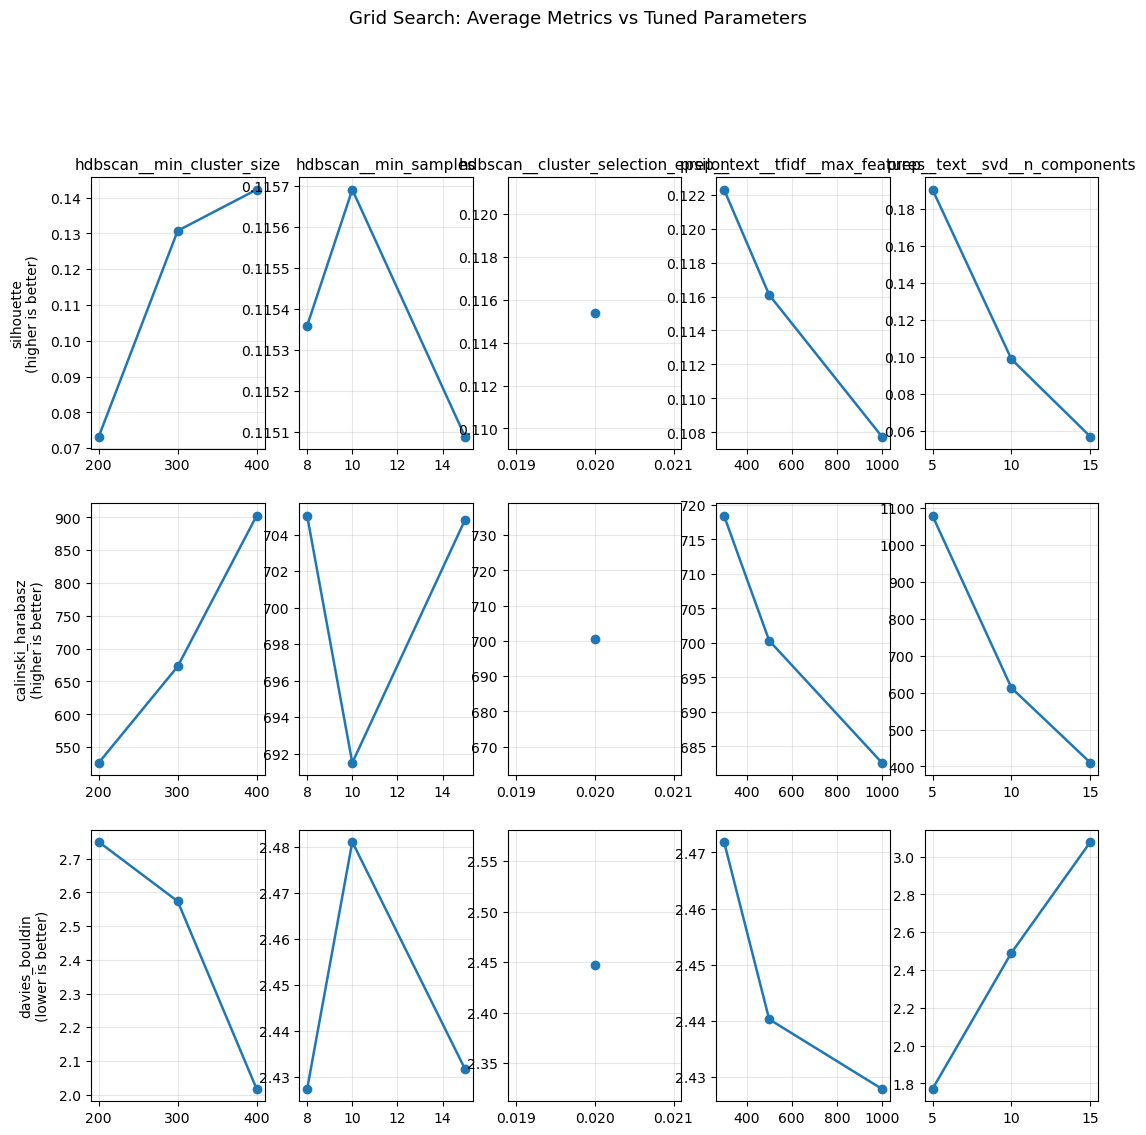



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.03 min
- 3D metric plots: 0.11 min

Total runtime: 0.14 minutes.


In [120]:
# Test full grid evaluator

grid_evaluator(hdbscan_renos_results, model = 'hdbscan')

For hdbscan,

**Best silhouette score so far**: silhouette=0.2794  | hdbscan__cluster_selection_epsilon=0.04, hdbscan__cluster_selection_method=leaf, hdbscan__min_cluster_size=250, hdbscan__min_samples=30, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=5, noise_frac=0.4758095238095238  | time=0.95 min

### Demolitions

In [81]:
# Load first builds hdbscan grid search results

hdbscan_demos_results_list = []

hdbscan_demos_results_01 = read_grid_results_csv('DEMOS/HDBSCAN','01_hdbscan_grid_results_demos.csv')

hdbscan_demos_results_list.append(hdbscan_demos_results_01)

# examine_df('first demos results from hdbscan', hdbscan_demos_results_01)

In [115]:
# Load first builds hdbscan grid search results

hdbscan_demos_results_list = []

hdbscan_demos_results_02 = read_grid_results_csv('DEMOS/HDBSCAN','02_hdbscan_grid_results_demos.csv')

hdbscan_demos_results_list.append(hdbscan_demos_results_02)

# examine_df('first demos results from hdbscan', hdbscan_demos_results_01)

In [116]:
# Merge vertically (row bind)

hdbscan_demos_results = pd.concat(
    hdbscan_demos_results_list,
    axis=0,          # stack rows
    ignore_index=True  # reset index
)

# examine_df('all hdbscan demos results', hdbscan_demos_results)



Printing top parameter configurations by metric...


=== Top parameter configurations by metric ===

Metric: silhouette  (higher is better)
  • silhouette=0.6713  | hdbscan__cluster_selection_epsilon=0.02, hdbscan__cluster_selection_method=eom, hdbscan__min_cluster_size=100, hdbscan__min_samples=15, prep__text__svd__n_components=10, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=14, noise_frac=0.1895344767238362  | time=0.36 min

Metric: calinski_harabasz  (higher is better)
  • calinski_harabasz=3409.7390  | hdbscan__cluster_selection_epsilon=0.02, hdbscan__cluster_selection_method=eom, hdbscan__min_cluster_size=200, hdbscan__min_samples=15, prep__text__svd__n_components=5, prep__text__tfidf__max_features=300, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=12, noise_frac=0.1307315365768288  | time=0.35 min

Metric: davies_bouldin  (lower is better)
  • davies_bouldin=0.8548  | hdbscan__cluster_selection_epsilon=0

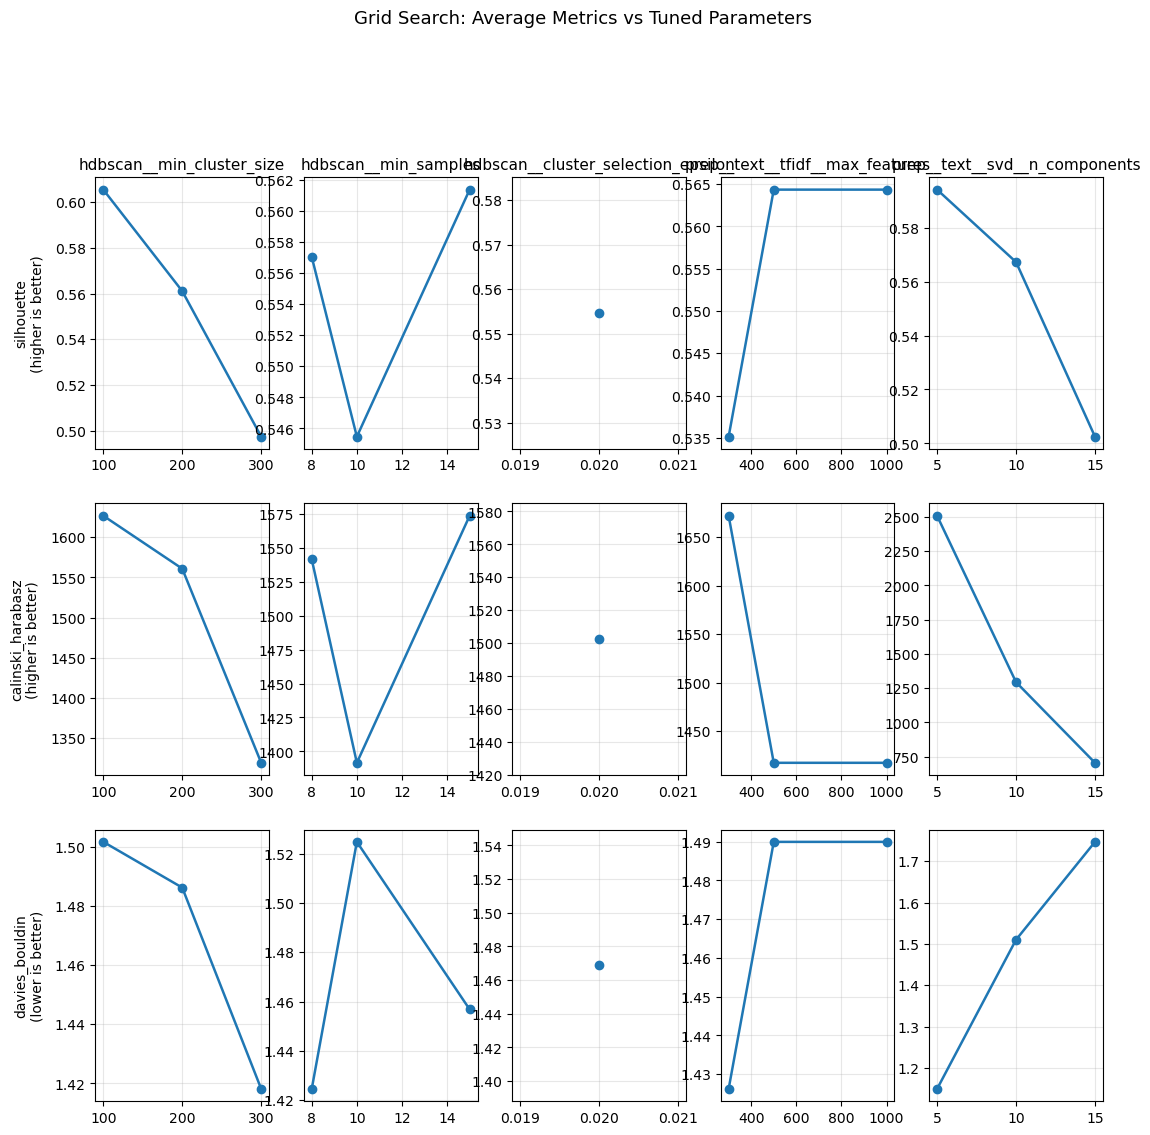



Rendering 3D metric views over the parameter grid...

  - 3D plot for metric: silhouette


  - 3D plot for metric: calinski_harabasz


  - 3D plot for metric: davies_bouldin




=== Step runtimes (minutes) ===
- Top parameter configs: 0.00 min
- Metric trend plots: 0.04 min
- 3D metric plots: 0.11 min

Total runtime: 0.15 minutes.


In [117]:
# Test full grid evaluator

grid_evaluator(hdbscan_demos_results, model = 'hdbscan')

For hdbscan,

**Best silhouette score so far**: silhouette=0.7145  | hdbscan__cluster_selection_epsilon=0.02, hdbscan__cluster_selection_method=leaf, hdbscan__min_cluster_size=250, hdbscan__min_samples=20, inertia=nan, aic=nan, bic=nan, avg_loglik=nan, n_clusters_found=11, noise_frac=0.1928596429821491  | time=0.35 min

## Grid Search Interpretation Tools

In [22]:
# Define function to extract list of all tested combos 

def list_tested_param_combos(
    results_df: pd.DataFrame,
    model: str = "kmeans") -> pd.DataFrame:
    
    """
    Return a neat table of all unique parameter combinations that were tested,
    with a 'trials' column indicating how many times each combo appeared.
    """

    # --- Pick defaults based on model ---
    if model == "kmeans":
        param_cols = (
            "kmeans__n_clusters",
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
    elif model == "gmm":
        param_cols = (
            "gmm__n_components",
            "gmm__covariance_type",
            "gmm__reg_covar",
            "gmm__n_init",
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
    elif model == 'agg':
        param_cols = (
            "agg__n_clusters",
            "agg__linkage",
            "agg__metric",        
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
    elif model == "hdbscan":
        param_cols = (
            "hdbscan__eps",
            "hdbscan__min_samples",
            "prep__text__svd__n_components",
            "prep__text__tfidf__max_features",
        )
        
    df = results_df.copy()

    # Collect parameter columns
    subset_cols = [c for c in param_cols if c in df.columns]

    # Convert numeric-like params to numeric; leave categorical as-is
    categorical_cols = {
        "gmm__covariance_type", "agg__linkage", "agg__metric"
    }
    for c in subset_cols:
        if c not in categorical_cols:
            df[c] = pd.to_numeric(df[c])

    combos = (
        df.dropna(subset=subset_cols)
          .groupby(subset_cols, as_index=False)
          .size()
          .rename(columns={"size": "trials"})
          .sort_values(subset_cols)
          .reset_index(drop=True)
    )

    # Cast integer-like floats to int for pretty printing
    for c in subset_cols:
        if pd.api.types.is_float_dtype(combos[c]) and (combos[c] % 1 == 0).all():
            combos[c] = combos[c].astype(int)

    print(f"{len(combos)} unique parameter combinations found.")
    return combos

In [23]:
# Define function to read grid search results csv as a dataframe

def read_grid_results_csv(folder,
                          name,
                          filepath = "C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS", 
                          skiprows = 7):
   
    """
    Read a grid search results CSV (with metadata in the first rows).
    """

    full_path = f"{filepath}/{folder}/{name}"
    
    # Peek through file until we find the header row of the results
    with open(full_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    header_row = None
    for i, line in enumerate(lines):
        # detect by presence of known column names
        if "inertia" in line and "silhouette" in line:
            header_row = i
            break

    if header_row is None:
        raise ValueError("Could not detect the results table header in the file.")

    # Now read with skiprows = header_row
    df = pd.read_csv(full_path, skiprows=header_row)

    return df

In [24]:
# Define function to save grid search results csv

def save_grid_results_csv(results_df, param_grid, 
                          filepath = "C:/Users/emshe/Desktop/BRAINSTATION/CAPSTONE/GIT_REPO/DATA/RESULTS",
                          filename = "grid_search_results",
                             title = "Grid search results"):
    
    """
    Save a CSV with the parameter grid written at the top, followed by the grid search results DataFrame
    """

    filepath = filepath + '/' + filename
    
    # Make param grid readable
    header_lines = []
    header_lines.append(title)
    header_lines.append(f"Timestamp: {datetime.now().isoformat(timespec='seconds')}")
    header_lines.append("Parameter Grid:")
    for k in sorted(param_grid.keys()):
        v = param_grid[k]
        # prepend comma so Excel/CSV viewers start params in column B
        header_lines.append(f",- {k}: {json.dumps(v)}")
    header_lines.append("")  # blank line before the DataFrame

    # Write header + DataFrame to one CSV file
    with open(filepath, "w", encoding="utf-8", newline="") as f:
        f.write("\n".join(header_lines) + "\n")
        results_df.to_csv(f, index=False)

    print(f"Saved grid results to: {filepath}")

In [25]:
# Define function to check optimal parameter combo according to each metric

def print_top_configs(results_df, top_k = 1,
                      model = 'kmeans'):
    
    """
    Print the top parameter combos according to each metric in results_df
    """
    
    # Defaults by model
    if model == "kmeans":
        metric_cols = ("silhouette", "calinski_harabasz", "davies_bouldin", "inertia")
    elif model == "gmm":
        metric_cols = ("bic", "aic", "avg_loglik", "silhouette", "calinski_harabasz", "davies_bouldin")
    elif model in ("agg", "agglomerative"):
        metric_cols = ("silhouette", "calinski_harabasz", "davies_bouldin")
    elif model == "hdbscan":
        metric_cols = ("silhouette", "calinski_harabasz", "davies_bouldin")

    # Which direction is better for each metric?
    higher_better = {
        "silhouette": True,
        "calinski_harabasz": True,
        "davies_bouldin": False,
        "inertia": False,
        "aic": False,
        "bic": False,
        "avg_loglik": True,
    }

    # Columns that are *not* params (we won't print them as params)
    non_param_cols = set(metric_cols) | {"fit_time_s", "index"}

    # Auto-detect param columns
    param_cols = [c for c in results_df.columns if c not in non_param_cols]

    print("\n=== Top parameter configurations by metric ===")
    
    for m in metric_cols:
        dfm = results_df.dropna(subset=[m]).copy()
        asc = not higher_better.get(m, True)  # lower is better -> ascending True
        top = dfm.sort_values(m, ascending=asc).head(top_k)

        print(f"\nMetric: {m}  ({'higher' if not asc else 'lower'} is better)")
        for i, row in top.iterrows():
            params_str = ", ".join(f"{p}={row[p]}" for p in param_cols)
            fit_min = (row.get("fit_time_s", float('nan')) or float('nan')) / 60
            print(f"  • {m}={row[m]:.4f}  | {params_str}  | time={fit_min:.2f} min")

In [26]:
# Define function to plot metric trends after grid search

def plot_metric_trends(results_df, model = 'kmeans'):
    """
    Plot average metrics vs each tuned parameter.
    """

    if model == "kmeans":
        metric_cols = ["silhouette", "calinski_harabasz", "davies_bouldin", "inertia"]
        param_cols  = ["kmeans__n_clusters",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    elif model == "gmm":
        metric_cols = ["bic", "aic", "avg_loglik", "silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols  = ["gmm__n_components",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    elif model == "agg":
        metric_cols = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols  = ["agg__n_clusters",
                       "agg__linkage",
                       "agg__metric",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    elif model == "hdbscan":
        metric_cols = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols  = ["hdbscan__min_cluster_size",
                       "hdbscan__min_samples",
                       "hdbscan__cluster_selection_epsilon",
                       "prep__text__tfidf__max_features",
                       "prep__text__svd__n_components"]

    # Keep only those that actually exist in the df
    metric_cols = [m for m in metric_cols if m in results_df.columns]
    param_cols  = [p for p in param_cols if p in results_df.columns]
    
    n_rows = len(metric_cols)
    n_cols = len(param_cols)

    # increase vertical size to give rows more breathing room
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 12), squeeze=False)

    metric_notes = {
        "silhouette": "(higher is better)",
        "calinski_harabasz": "(higher is better)",
        "davies_bouldin": "(lower is better)",
        "inertia": "(lower is better)",
        "aic": "(lower is better)",
        "bic": "(lower is better)",
        "avg_loglik": "(higher is better)",
    }
    
    for r, metric in enumerate(metric_cols):
        for c, param in enumerate(param_cols):
            ax = axes[r, c]

            if param not in results_df.columns or metric not in results_df.columns:
                ax.set_visible(False)
                continue

            gp = (results_df[[param, metric]]
                  .dropna()
                  .groupby(param, as_index=False)
                  .mean())

            if gp.empty:
                ax.set_visible(False)
                continue

            # numeric x if possible; else treat as categorical
            try:
                gp[param] = pd.to_numeric(gp[param])
                gp = gp.sort_values(param)
                xvals = gp[param]
            except Exception:
                gp[param] = gp[param].astype(str)
                gp = gp.sort_values(param)
                xvals = gp[param]

            ax.plot(xvals, gp[metric], marker='o', linewidth=1.8)
            ax.grid(True, alpha=0.3)

            if r == 0:
                ax.set_title(param, fontsize=11)

            if c == 0:
                # 2-line vertical y-label: metric on line 1, note on line 2
                note = metric_notes.get(metric, "")
                ax.set_ylabel(f"{metric}\n{note}", fontsize=10, rotation=90,
                              va="center", ha="center")
                ax.yaxis.labelpad = 18  # add some space from tick labels

            ax.set_xlabel("")

    fig.suptitle("Grid Search: Average Metrics vs Tuned Parameters", fontsize=13, y=1.02)
    plt.show()


In [27]:
# Define function to print 3D scatter plot of grid search

def plot_grid_3d_metric(results_df,
                        metric,
                        model = "kmeans"):
    """
    3D Plotly scatter of grid search results
    """

    # Choose default param columns by model
    x_col = "prep__text__tfidf__max_features"
    y_col = "prep__text__svd__n_components"
    
    if model == "kmeans":
        z_col = "kmeans__n_clusters"
    elif model == "gmm":
        z_col = "gmm__n_components"
    elif model in ("agg", "agglomerative"):
        z_col = "agg__n_clusters"
    elif model == "hdbscan":
        z_col = "hdbscan__min_samples"
    else:
        # fallback: first available
        for cand in ["kmeans__n_clusters","gmm__n_components","agg__n_clusters","hdbscan__min_samples"]:
            if cand in results_df.columns:
                z_col = cand
                break
        else:
            raise ValueError("No suitable z-axis parameter column found.")
    
    param_cols = (x_col, y_col, z_col)

    # Basic checks
    missing = [c for c in (x_col, y_col, z_col, metric) if c not in results_df.columns]
    if missing:
        raise ValueError(f"Missing required column(s): {missing}")

    df = results_df.dropna(subset=[metric]).copy()

    # Keep originals for hover
    df["_x_orig"] = df[x_col]
    df["_y_orig"] = df[y_col]
    df["_z_orig"] = df[z_col]

    # Simple min–max scaling
    for src, dst in [(x_col, "x_scaled"), (y_col, "y_scaled"), (z_col, "z_scaled")]:
        s = pd.to_numeric(df[src], errors="coerce")
        lo, hi = s.min(), s.max()
        denom = (hi - lo) if pd.notna(hi) and pd.notna(lo) else np.nan
        if pd.isna(denom) or denom == 0:
            df[dst] = 0.0  # flat axis if only one value
        else:
            df[dst] = (s - lo) / denom

    # Metric direction (for colorscale)
    higher_better = {
        "silhouette": True,
        "calinski_harabasz": True,
        "davies_bouldin": False,
        "inertia": False,
        "aic": False,
        "bic": False,
        "avg_loglik": True,
    }
    hb = higher_better.get(metric, True)
    colorscale = "Viridis" if hb else "Viridis_r"

    # axis label map
    axis_labels = {
        "prep__text__tfidf__max_features": "tfidf_feats",
        "prep__text__svd__n_components": "svd_comp",
        "kmeans__n_clusters": "n_clusters",
        "gmm__n_components": "n_components",
        "agg__n_clusters": "n_clusters",
        "hdbscan__min_samples": "min_samples",
    }

    fig = px.scatter_3d(
        df,
        x="x_scaled", y="y_scaled", z="z_scaled",
        color=metric,
        color_continuous_scale=colorscale,
        title=f"Grid Search 3D: {metric} ({'higher' if hb else 'lower'} is better)",
        hover_data={
            metric: ':.4f',
            x_col: True, y_col: True, z_col: True,
            "_x_orig": False, "_y_orig": False, "_z_orig": False,
        },
        opacity=0.85
    )

    fig.update_traces(marker=dict(size=4))
    fig.update_layout(
        scene=dict(
            xaxis=dict(title=axis_labels.get(x_col, x_col), range=[0, 1]),
            yaxis=dict(title=axis_labels.get(y_col, y_col), range=[0, 1]),
            zaxis=dict(title=axis_labels.get(z_col, z_col), range=[0, 1]),
        ),
        coloraxis_colorbar=dict(title=metric)
    )
    return fig



In [28]:
# Define function to run all grid search interpretation tools

def grid_evaluator(results_df,
                   model="kmeans",
                   run_print=True,
                   run_trends=True,
                   run_3d=True,
                   sleep_sec=2.0):
    
    """
    Run a subset of grid interpretation utilities
    """

  # Choose metrics & params by model 
    if model == "kmeans":
        metrics = ["silhouette", "calinski_harabasz", "davies_bouldin", "inertia"]
        param_cols = ["kmeans__n_clusters",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]

    elif model == "gmm":
        metrics = ["bic", "aic", "avg_loglik", "silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols = ["gmm__n_components",
                      "gmm__covariance_type",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]

    elif model in ("agg", "agglomerative"):
        metrics = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols = ["agg__n_clusters",
                      "agg__linkage",
                      "agg__metric",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]

    elif model == "hdbscan":
        metrics = ["silhouette", "calinski_harabasz", "davies_bouldin"]
        param_cols = ["hdbscan__eps",
                      "hdbscan__min_samples",
                      "prep__text__tfidf__max_features",
                      "prep__text__svd__n_components"]
    else:
        metric_candidates = ["bic","aic","avg_loglik","silhouette","calinski_harabasz","davies_bouldin","inertia"]
        param_candidates  = ["kmeans__n_clusters",
                             "gmm__n_components","gmm__covariance_type",
                             "agg__n_clusters","agg__linkage","agg__metric",
                             "hdbscan__eps","hdbscan__min_samples",
                             "prep__text__tfidf__max_features","prep__text__svd__n_components"]
        metrics = [m for m in metric_candidates if m in results_df.columns]
        param_cols = [p for p in param_candidates if p in results_df.columns]

    # Keep only columns that actually exist in the DF
    metrics   = [m for m in metrics   if m in results_df.columns]
    param_cols = [p for p in param_cols if p in results_df.columns]

    runtimes = {}
    start_all = time.time()

    if run_print:
        print("\n\nPrinting top parameter configurations by metric...\n")
        t0 = time.time()
        # Uses its own model-specific defaults; we pass model only
        print_top_configs(results_df, top_k=1, model=model)
        runtimes["Top parameter configs"] = (time.time() - t0) / 60

    if run_trends:
        print("\n\nPlotting metric trends vs tuned parameters...\n")
        t0 = time.time()
        plot_metric_trends(results_df, model=model)
        runtimes["Metric trend plots"] = (time.time() - t0) / 60

    if run_3d:
        if not metrics:
            print("\n\nNo metrics found to render in 3D; skipping.")
        else:
            print("\n\nRendering 3D metric views over the parameter grid...\n")
            t0 = time.time()
            for m in metrics:
                print(f"  - 3D plot for metric: {m}")
                # Let the 3D helper pick axes by model
                fig = plot_grid_3d_metric(results_df, metric=m, model=model)
                fig.show()
                time.sleep(sleep_sec)  # throttle Plotly renders
            runtimes["3D metric plots"] = (time.time() - t0) / 60

    total_min = (time.time() - start_all) / 60
    print("\n\n=== Step runtimes (minutes) ===")
    for name, mins in runtimes.items():
        print(f"- {name}: {mins:.2f} min")
    print(f"\nTotal runtime: {total_min:.2f} minutes.")